# **13. Comparación Final**

## **13.1. LibrerÍas**

In [1]:
import os
import pandas as pd
from scipy import stats
import numpy as np
from scipy.stats import shapiro
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene

from itertools import combinations

## **13.2. Cargar Resultados**

Inicialmente se cargan los resultados de todos los modelos para relaizar la comparación final.

In [2]:
BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"
MODELOS  = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV", "ECT_CV"]

METRICS_BASE = ["RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
                "SkillScore", "RMSE_top10", "Pearson_r", "Bias"]

def load_metrics(model_path, model_name):
    all_files = [f for f in os.listdir(model_path) if f.endswith(".csv")]

    results_files = [f for f in all_files
                     if f.lower().endswith("_results.csv")
                     and "spatial" not in f.lower()
                     and "fold" not in f.lower()]

    spatial_files = [f for f in all_files
                     if "spatial" in f.lower() and f.lower().endswith(".csv")]

    result = {}

    if results_files:
        fp = os.path.join(model_path, results_files[0])
        df = pd.read_csv(fp)
        meta_cols = [c for c in df.columns if not c.startswith(("real_", "log_"))]
        real_cols = [c for c in df.columns if c.startswith("real_")]
        if real_cols:
            result["global"] = df[meta_cols + real_cols].copy()
            result["global"]["Model"] = model_name
            
        
    if spatial_files:
        fp = os.path.join(model_path, spatial_files[0])
        df = pd.read_csv(fp)
        metric_cols  = [c for c in df.columns if c in METRICS_BASE]
        other_cols   = [c for c in df.columns if c not in METRICS_BASE]
        if metric_cols:
            result["spatial"] = df[other_cols + metric_cols].copy()
            result["spatial"]["Model"] = model_name
           

    return result


global_list  = []
spatial_list = []

for model in MODELOS:
    model_path = os.path.join(BASE_DIR, model)

    result = load_metrics(model_path, model)

    if "global" in result:
        global_list.append(result["global"])
    if "spatial" in result:
        spatial_list.append(result["spatial"])

metrics_global_df  = pd.concat(global_list,  ignore_index=True) if global_list  else pd.DataFrame()
metrics_spatial_df = pd.concat(spatial_list, ignore_index=True) if spatial_list else pd.DataFrame()

for df in [metrics_global_df, metrics_spatial_df]:
    if not df.empty and "Model" in df.columns:
        cols = ["Model"] + [c for c in df.columns if c != "Model"]
        df.drop(columns=[c for c in df.columns if c not in cols], inplace=False)

metrics_global_df  = metrics_global_df[["Model"]  + [c for c in metrics_global_df.columns  if c != "Model"]]  if not metrics_global_df.empty  else metrics_global_df

In [4]:
metrics_df = metrics_global_df

In [ ]:
BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"
MODELOS  = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV", "ECT_CV"]

METRICS_BASE = ["RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
                "SkillScore", "RMSE_top10", "Pearson_r", "Bias"]

def load_metrics(model_path, model_name):
    all_files = [f for f in os.listdir(model_path) if f.endswith(".csv")]

    results_files = [f for f in all_files
                     if f.lower().endswith("_results.csv")
                     and "spatial" not in f.lower()
                     and "fold" not in f.lower()]

    spatial_files = [f for f in all_files
                     if "spatial" in f.lower() and f.lower().endswith(".csv")]

    result = {}

    if results_files:
        fp = os.path.join(model_path, results_files[0])
        df = pd.read_csv(fp)
        meta_cols = [c for c in df.columns if not c.startswith(("real_", "log_"))]
        real_cols = [c for c in df.columns if c.startswith("real_")]
        if real_cols:
            result["global"] = df[meta_cols + real_cols].copy()
            result["global"]["Model"] = model_name
            
        
    if spatial_files:
        fp = os.path.join(model_path, spatial_files[0])
        df = pd.read_csv(fp)
        metric_cols  = [c for c in df.columns if c in METRICS_BASE]
        other_cols   = [c for c in df.columns if c not in METRICS_BASE]
        if metric_cols:
            result["spatial"] = df[other_cols + metric_cols].copy()
            result["spatial"]["Model"] = model_name
           

    return result


global_list  = []
spatial_list = []

for model in MODELOS:
    model_path = os.path.join(BASE_DIR, model)

    result = load_metrics(model_path, model)

    if "global" in result:
        global_list.append(result["global"])
    if "spatial" in result:
        spatial_list.append(result["spatial"])

metrics_global_df  = pd.concat(global_list,  ignore_index=True) if global_list  else pd.DataFrame()
metrics_spatial_df = pd.concat(spatial_list, ignore_index=True) if spatial_list else pd.DataFrame()

for df in [metrics_global_df, metrics_spatial_df]:
    if not df.empty and "Model" in df.columns:
        cols = ["Model"] + [c for c in df.columns if c != "Model"]
        df.drop(columns=[c for c in df.columns if c not in cols], inplace=False)

metrics_global_df  = metrics_global_df[["Model"]  + [c for c in metrics_global_df.columns  if c != "Model"]]  if not metrics_global_df.empty  else metrics_global_df
metrics_spatial_df = metrics_spatial_df[["Model"] + [c for c in metrics_spatial_df.columns if c != "Model"]]  if not metrics_spatial_df.empty else metrics_spatial_df

### **13.2.1. Métricas test_year por modelo**

In [40]:
real_cols = [c for c in metrics_global_df.columns if c.startswith("real_")]

summary_df = (
    metrics_global_df
    .groupby(["Model", "test_year"])[real_cols]
    .agg(["mean", "std"])
    .round(4)
)

summary_df.columns = [f"{col}_{stat}" for col, stat in summary_df.columns]
summary_df = summary_df.reset_index()

display(summary_df)

,Model,test_year,real_RMSE_mean,real_RMSE_std,real_MAE_mean,real_MAE_std,real_MAPE_mean,real_MAPE_std,real_sMAPE_mean,real_sMAPE_std,...,real_KGE_mean,real_KGE_std,real_SkillScore_mean,real_SkillScore_std,real_RMSE_top10_mean,real_RMSE_top10_std,real_Pearson_r_mean,real_Pearson_r_std,real_Bias_mean,real_Bias_std
0,ConvLSTM_CV,2022,3.4168,0.3865,1.4761,0.1340,26.8545,1.2016,29.1579,1.1329,...,0.3264,0.1111,0.4813,0.0938,10.0348,1.2388,0.8240,0.0175,-1.1562,0.1801
1,ConvLSTM_CV,2023,3.5758,0.4807,1.9437,0.2157,30.3185,0.2956,32.3874,1.3548,...,0.5603,0.2052,0.6060,0.1196,9.7129,1.7903,0.8474,0.0068,-1.3186,0.5161
2,ConvLSTM_CV,2024,6.9161,1.2933,4.3785,0.7710,40.8715,2.4196,47.0800,7.2408,...,0.4372,0.2520,0.4396,0.1626,17.4716,3.8719,0.8244,0.0324,-3.5632,1.5132
3,ECT_CV,2022,2.5462,0.0549,1.1412,0.0221,23.9219,0.9324,23.1174,0.6921,...,0.6251,0.0667,0.7126,0.0109,7.2294,0.3062,0.8729,0.0123,-0.5066,0.2321
4,ECT_CV,2023,3.2486,0.1392,1.6392,0.0442,27.9833,0.5840,25.7339,0.6390,...,0.7039,0.0661,0.6832,0.0097,8.7654,0.5589,0.8376,0.0068,-0.6131,0.2673
5,ECT_CV,2024,4.6867,0.4323,2.7489,0.2057,31.9170,1.1979,26.7691,0.4618,...,0.7741,0.1129,0.7521,0.0236,11.1340,1.9514,0.8788,0.0136,-0.5547,0.6346
6,LSTM_CV,2022,2.5536,0.1083,1.1471,0.0256,23.5691,1.3594,23.4475,0.7011,...,0.6295,0.0305,0.7032,0.0295,7.2839,0.3963,0.8614,0.0151,-0.5527,0.0367
7,LSTM_CV,2023,3.5251,0.2023,1.7012,0.0497,28.2886,0.8444,26.0355,1.3072,...,0.6919,0.1099,0.6553,0.0474,9.5403,1.0663,0.8203,0.0138,-0.5268,0.3976
8,LSTM_CV,2024,5.9420,0.7643,3.3860,0.2499,36.2004,2.8932,29.7023,1.1327,...,0.6284,0.1419,0.6296,0.0793,15.2211,3.6882,0.8157,0.0202,-0.7780,0.9090
9,STGNN_CV,2022,4.0551,0.2484,1.9340,0.1213,46.7965,3.6219,42.2657,2.9525,...,0.1965,0.1166,0.2770,0.1063,11.8903,0.8910,0.6172,0.0754,-0.9916,0.1994


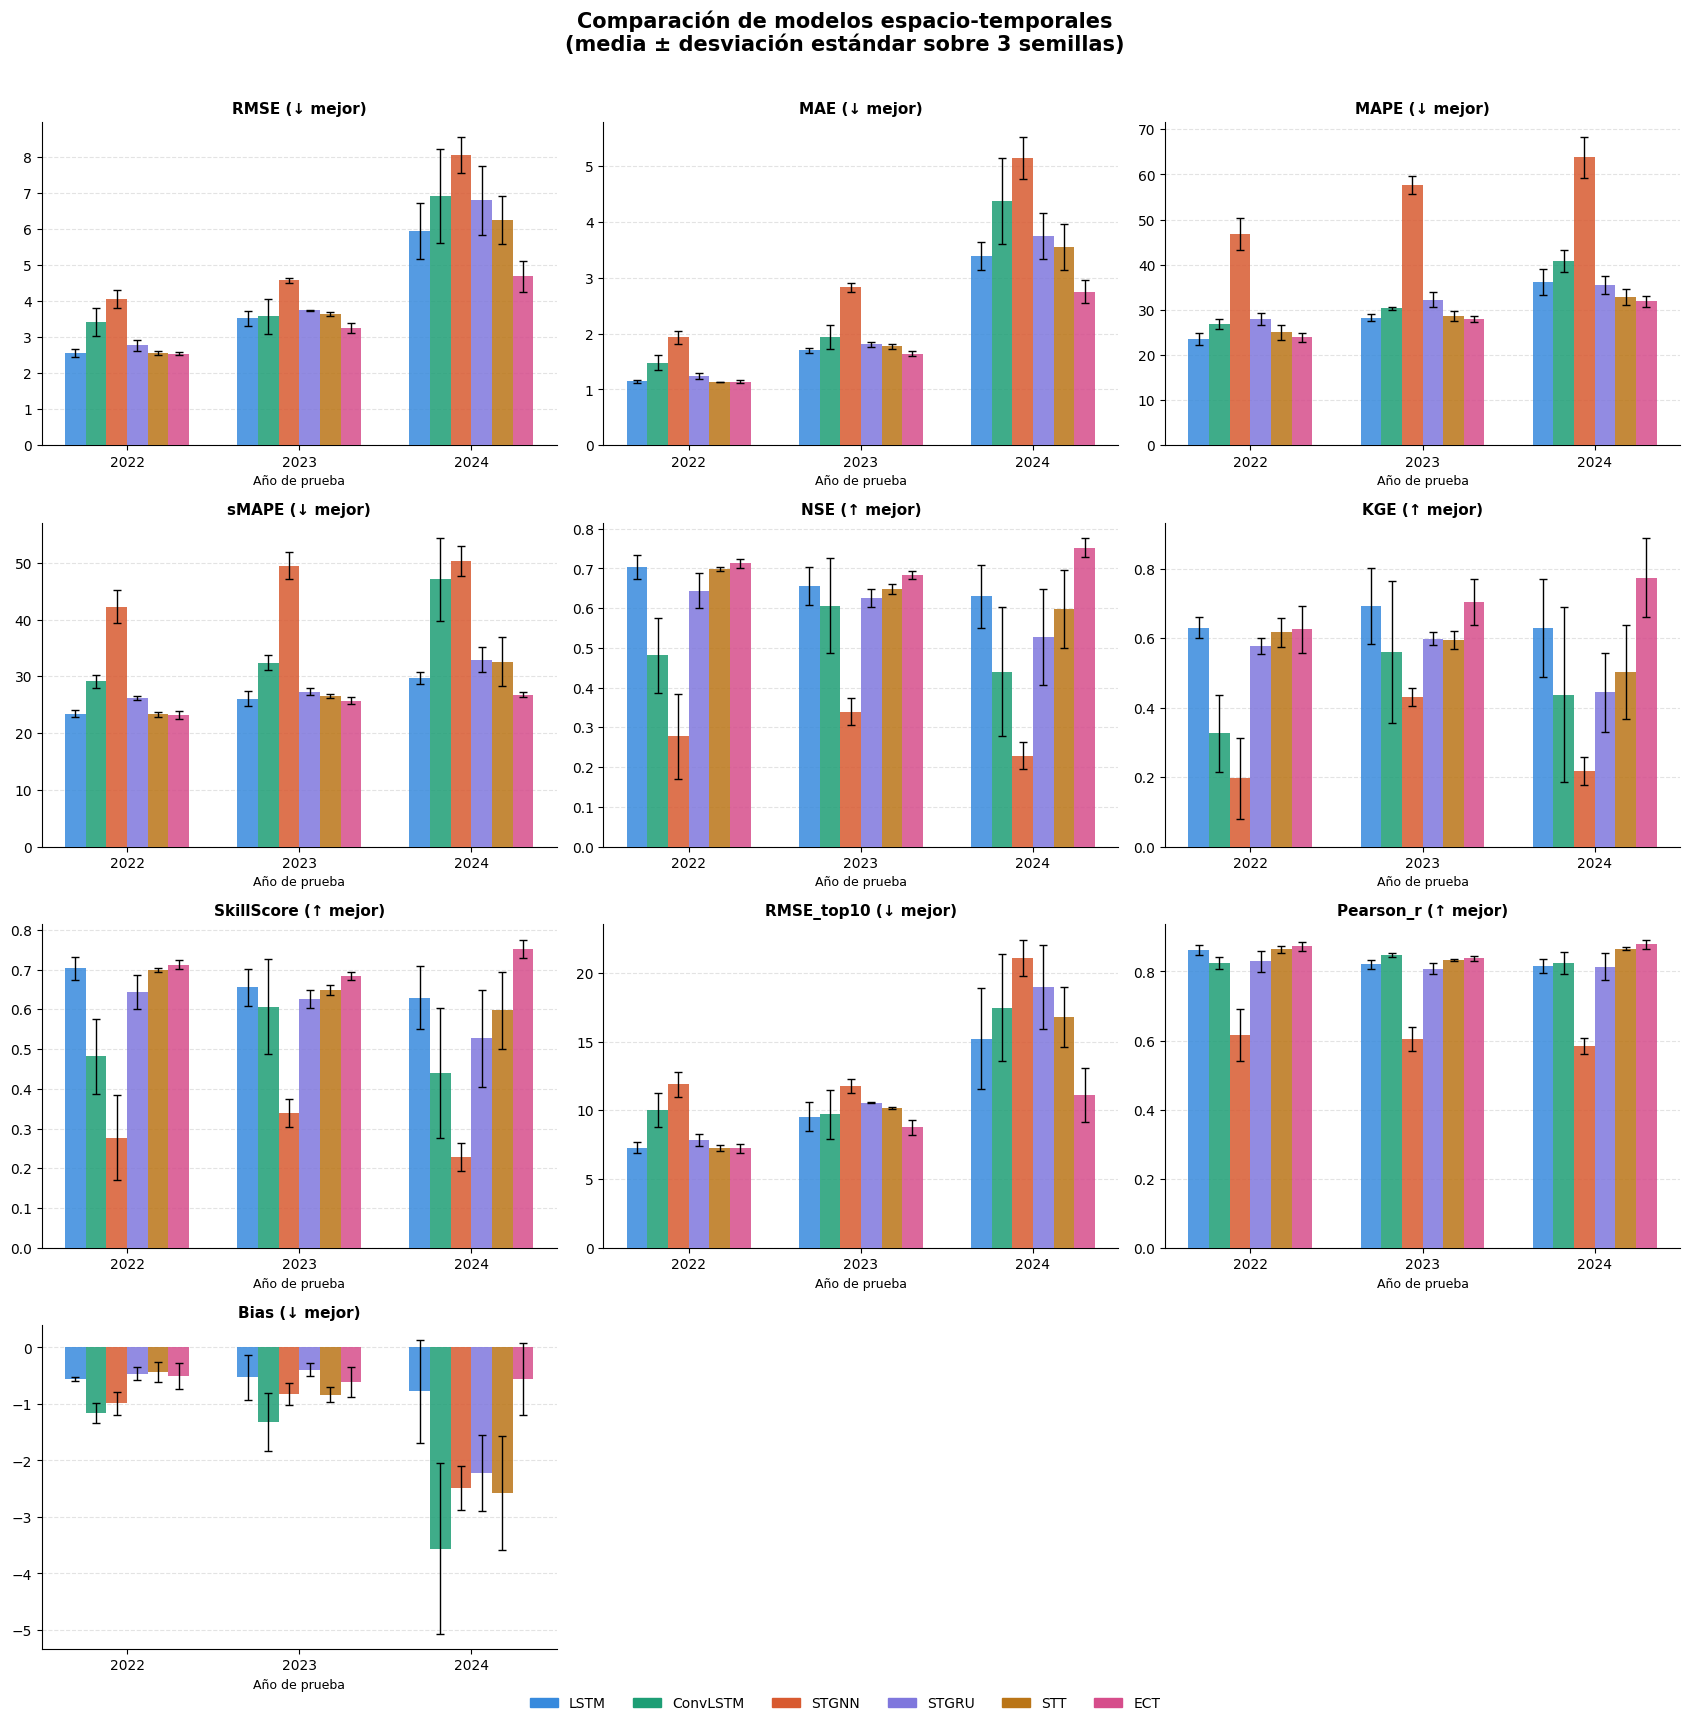

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

real_cols_mean = [
    c for c in summary_df.columns
    if c.endswith("_mean") and c.startswith("real_")
]

metrics = [
    c.replace("real_", "").replace("_mean", "")
    for c in real_cols_mean
]

models = [
    "LSTM_CV",
    "ConvLSTM_CV",
    "STGNN_CV",
    "STGRU_CV",
    "STT_CV",
    "ECT_CV"
]

models = [m for m in models if m in summary_df["Model"].unique()]

years = sorted(summary_df["test_year"].unique())

colors = [
    "#378ADD",  
    "#1D9E75",  
    "#D85A30",  
    "#7F77DD",  
    "#BA7517",  
    "#D64D8B"   
]

mod_col = dict(zip(models, colors))


lower_better = {
    "RMSE",
    "MAE",
    "MAPE",
    "sMAPE",
    "RMSE_top10",
    "Bias"
}

higher_better = {
    "NSE",
    "KGE",
    "SkillScore",
    "Pearson_r"
}

n_metrics = len(metrics)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, n_rows * 4.2)
)

axes = axes.flatten()

x = np.arange(len(years))

width = 0.12

offsets = np.linspace(
    -(len(models)-1)/2,
    (len(models)-1)/2,
    len(models)
) * width


for i, metric in enumerate(metrics):

    ax = axes[i]

    mean_col = f"real_{metric}_mean"
    std_col  = f"real_{metric}_std"

    for j, model in enumerate(models):

        df_m = (
            summary_df[
                summary_df["Model"] == model
            ]
            .sort_values("test_year")
        )

        if df_m.empty:
            continue

        means = df_m[mean_col].values
        stds  = df_m[std_col].values

        ax.bar(
            x + offsets[j],
            means,
            width,
            color=mod_col[model],
            alpha=0.85,
            zorder=3
        )

        ax.errorbar(
            x + offsets[j],
            means,
            yerr=stds,
            fmt="none",
            color="black",
            capsize=3,
            linewidth=1,
            zorder=4
        )

    direction = (
        "↓ mejor"
        if metric in lower_better
        else "↑ mejor"
    )

    ax.set_title(
        f"{metric} ({direction})",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(years)

    ax.set_xlabel("Año de prueba", fontsize=9)

    ax.yaxis.grid(
        True,
        linestyle="--",
        alpha=0.35
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)
    
handles = [
    mpatches.Patch(
        color=mod_col[m],
        label=m.replace("_CV", "")
    )
    for m in models
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(models),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Comparación de modelos espacio-temporales\n"
    "(media ± desviación estándar sobre 3 semillas)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "comparacion_modelos_espaciotemporales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A lo largo de los tres años de prueba (2022, 2023 y 2024), el **ECT** emerge
consistentemente como el modelo de mejor desempeño global, destacándose en prácticamente
todas las métricas relevantes: registra los mayores valores de NSE (alcanzando ~0.75 en 2024),
KGE (cercano a 0.80 en 2024), Skill Score (~0.75 en 2024) y Pearson_r (superior a 0.85 en
todos los años), al tiempo que mantiene los menores errores porcentuales (MAPE y sMAPE entre
los más bajos) y el RMSE_top10 más reducido, lo que indica que también maneja mejor los
eventos extremos. Lo más llamativo del ECT es que, a diferencia del resto de los modelos que
se deterioran en 2024, su desempeño en métricas de ajuste como NSE, KGE y Skill Score
**mejora o se mantiene estable**, sugiriendo una mayor robustez frente a condiciones
hidrológicas atípicas. En cuanto al Bias, el ECT se mantiene en el rango negativo pero
moderado, sin los colapsos extremos que muestran ConvLSTM y STGNN en 2024. Por su parte,
el **LSTM** y el **STT** continúan siendo los segundos mejores modelos, competitivos en
error absoluto pero claramente superados por ECT en métricas de ajuste global. El **STGNN**
reafirma su posición como el modelo de peor desempeño: lidera en MAPE (~47% en 2022, ~58%
en 2023 y ~64% en 2024), presenta los Skill Score y NSE más bajos, y muestra la mayor
inestabilidad entre semillas con barras de error amplias en casi todas las métricas. En
síntesis, la incorporación del **ECT como modelo de referencia superior redefine el ranking**:
ECT > LSTM ≈ STT > STGRU > ConvLSTM > STGNN, con una ventaja especialmente notable del
ECT en 2024, el año más exigente, lo que lo posiciona como la arquitectura más recomendable
para la predicción espacio-temporal en el contexto colombiano evaluado.

### **13.2.2. Métricas anuales por modelo**

In [42]:
summary_overall = (
    metrics_global_df
    .groupby("Model")[real_cols]
    .agg(["mean", "std"])
    .round(4)
)
summary_overall.columns = [f"{col}_{stat}" for col, stat in summary_overall.columns]
summary_overall = summary_overall.reset_index()

display(summary_overall)

,Model,real_RMSE_mean,real_RMSE_std,real_MAE_mean,real_MAE_std,real_MAPE_mean,real_MAPE_std,real_sMAPE_mean,real_sMAPE_std,real_NSE_mean,...,real_KGE_mean,real_KGE_std,real_SkillScore_mean,real_SkillScore_std,real_RMSE_top10_mean,real_RMSE_top10_std,real_Pearson_r_mean,real_Pearson_r_std,real_Bias_mean,real_Bias_std
0,ConvLSTM_CV,4.6362,1.8552,2.5994,1.4093,32.6815,6.4673,36.2084,9.0733,0.5089,...,0.4413,0.1994,0.5089,0.1342,12.4064,4.4027,0.8319,0.0220,-2.0127,1.4158
1,ECT_CV,3.4939,0.9722,1.8431,0.7206,27.9407,3.5563,25.2068,1.7123,0.7160,...,0.7010,0.0977,0.7160,0.0330,9.0429,1.9888,0.8631,0.0216,-0.5582,0.3662
2,LSTM_CV,4.0069,1.5629,2.0781,1.0179,29.3527,5.7694,26.3951,2.8773,0.6627,...,0.6499,0.0963,0.6627,0.0583,10.6818,4.0336,0.8325,0.0261,-0.6192,0.5106
3,STGNN_CV,5.5598,1.8981,3.3008,1.4464,56.0807,8.0441,47.3598,4.4739,0.2817,...,0.2819,0.1292,0.2817,0.0757,14.9218,4.7190,0.6023,0.0454,-1.4329,0.8317
4,STGRU_CV,4.4393,1.8773,2.2652,1.1557,31.9374,3.5798,28.8041,3.3597,0.5989,...,0.5396,0.0934,0.5989,0.0852,12.4724,5.2648,0.8171,0.0277,-1.0261,0.9606
5,STT_CV,4.1482,1.6754,2.1532,1.1064,28.8091,3.6071,27.5132,4.6306,0.6480,...,0.5711,0.0892,0.6480,0.0659,11.4159,4.3664,0.8544,0.0170,-1.2821,1.1101


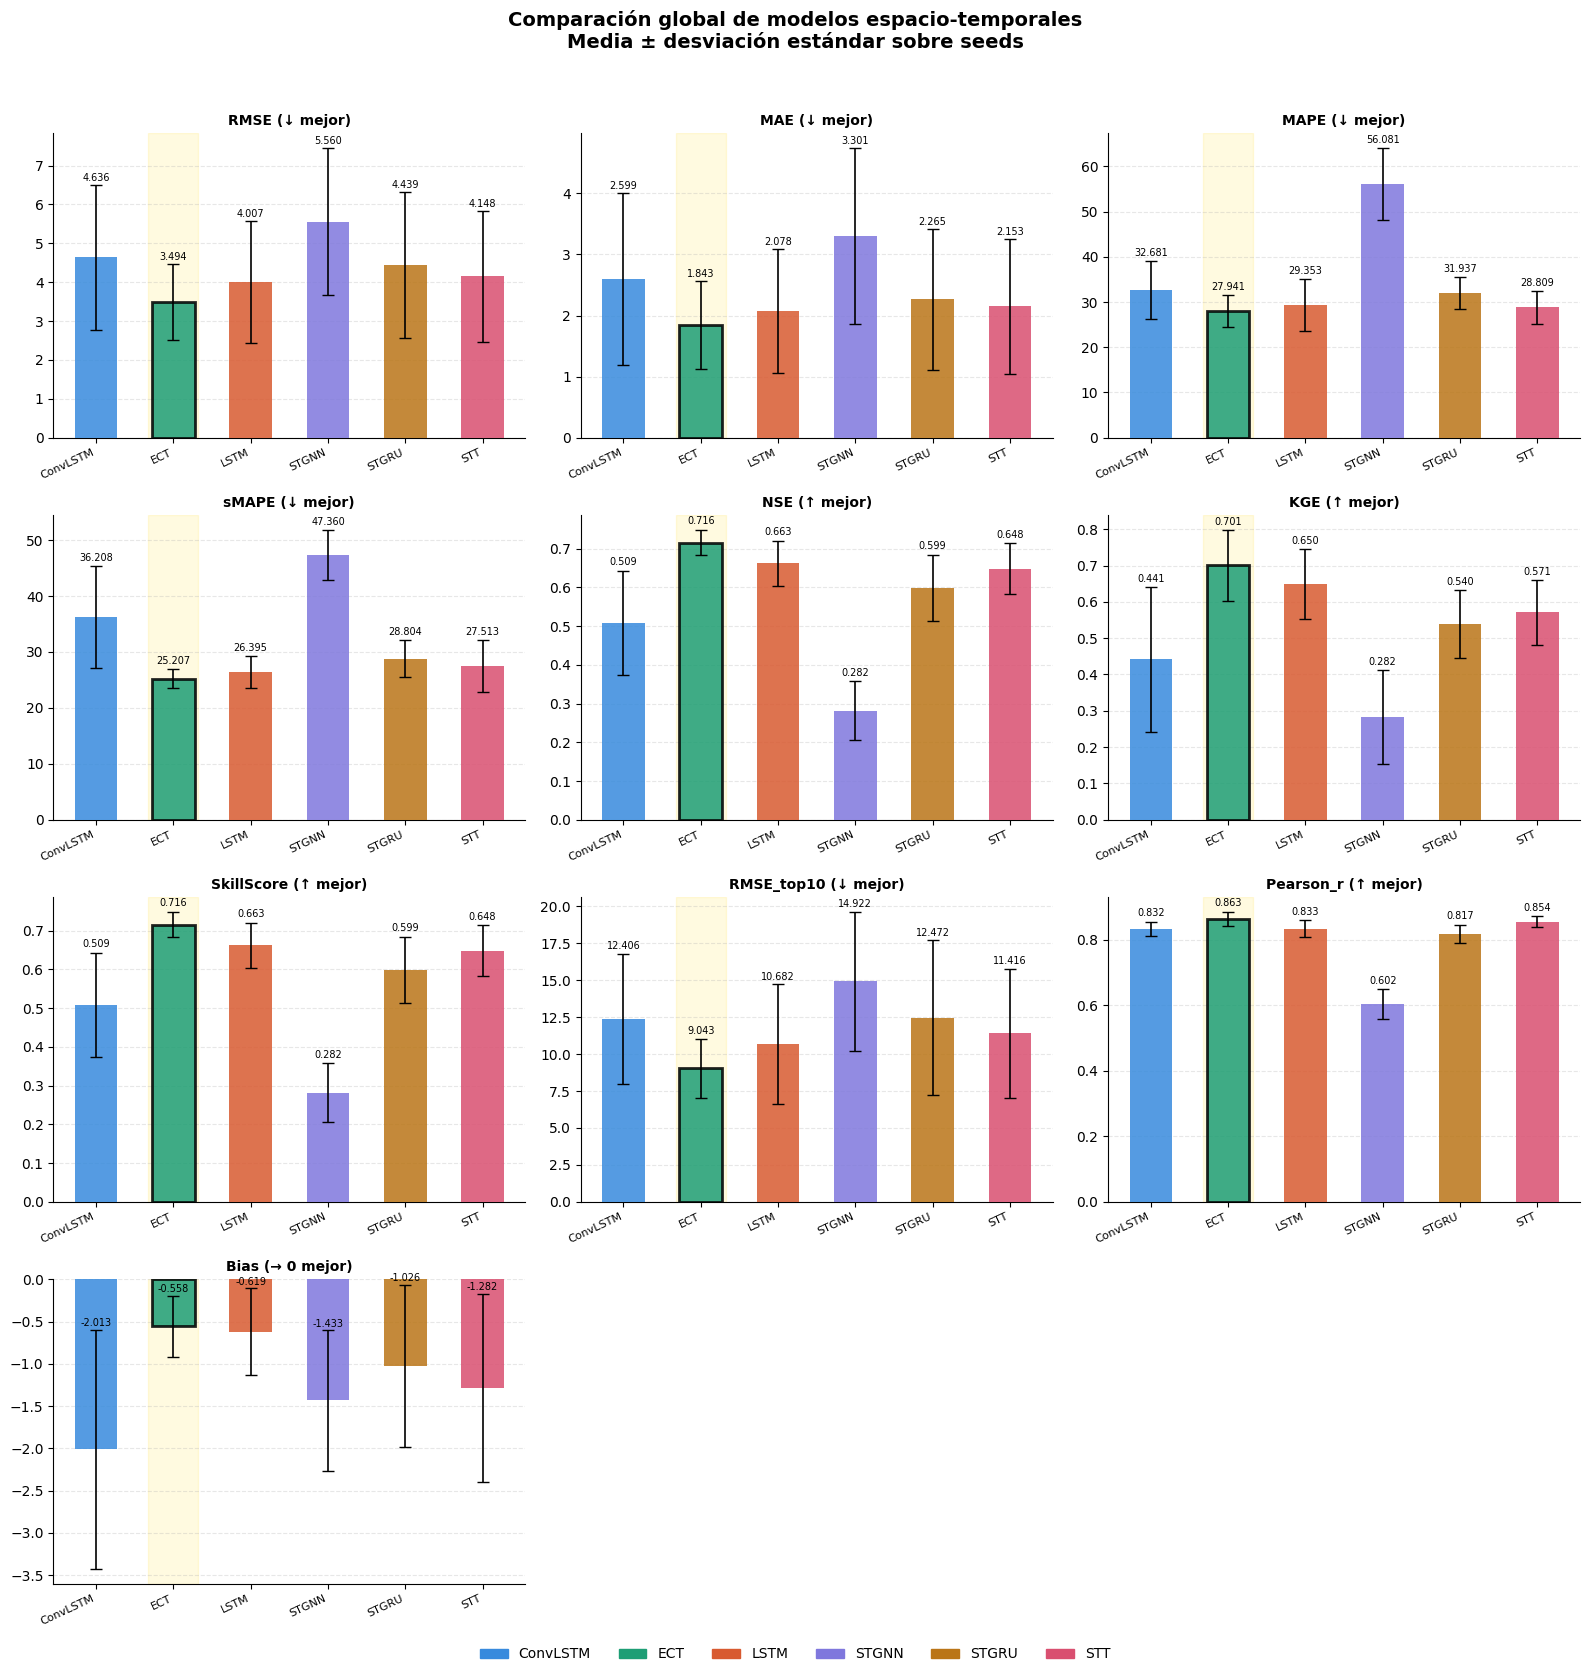

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = summary_overall["Model"].values

colors = [
    "#378ADD",  
    "#1D9E75", 
    "#D85A30",  
    "#7F77DD",  
    "#BA7517",  
    "#D94F70"   
]

mod_col = dict(zip(models, colors))

real_cols_mean = [
    c for c in summary_overall.columns
    if c.endswith("_mean") and c.startswith("real_")
]

metrics = [
    c.replace("real_", "").replace("_mean", "")
    for c in real_cols_mean
]

lower_better = {
    "RMSE", "MAE", "MAPE",
    "sMAPE", "RMSE_top10"
}

higher_better = {
    "NSE", "KGE",
    "SkillScore", "Pearson_r"
}

n_metrics = len(metrics)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 4)
)

axes = axes.flatten()

x = np.arange(len(models))
width = 0.55

for i, metric in enumerate(metrics):

    ax = axes[i]

    mean_col = f"real_{metric}_mean"
    std_col  = f"real_{metric}_std"

    means = summary_overall[mean_col].values
    stds  = summary_overall[std_col].values


    if metric in lower_better:
        best_idx = np.argmin(means)
        direction = "↓ mejor"

    elif metric in higher_better:
        best_idx = np.argmax(means)
        direction = "↑ mejor"

    else:  
        best_idx = np.argmin(np.abs(means))
        direction = "→ 0 mejor"

    bars = ax.bar(
        x,
        means,
        width,
        color=[mod_col[m] for m in models],
        alpha=0.85,
        zorder=3
    )

    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2)

    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.2,
        zorder=4
    )

    for j, bar in enumerate(bars):

        y_text = (
            means[j]
            + stds[j]
            + 0.02 * np.nanmax(np.abs(means))
        )

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y_text,
            f"{means[j]:.3f}",
            ha="center",
            fontsize=7
        )

    ax.axvspan(
        x[best_idx] - width/2 - 0.05,
        x[best_idx] + width/2 + 0.05,
        color="gold",
        alpha=0.12,
        zorder=0
    )

    ax.set_title(
        f"{metric} ({direction})",
        fontsize=10,
        fontweight="bold"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [m.replace("_CV", "") for m in models],
        rotation=25,
        ha="right",
        fontsize=8
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

handles = [
    mpatches.Patch(
        color=mod_col[m],
        label=m.replace("_CV", "")
    )
    for m in models
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=6,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Comparación global de modelos espacio-temporales\n"
    "Media ± desviación estándar sobre seeds",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    "comparacion_global_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La comparación global de los seis modelos, promediada sobre todos los folds espaciales, años
de prueba y semillas, confirma y consolida el liderazgo del **ECT** como la arquitectura de
mejor desempeño integral. Con el menor RMSE (3.494), el menor MAE (1.843) y el menor sMAPE
(25.207) del conjunto, junto con el mayor NSE (0.716), el mayor KGE (0.701), el mayor Skill
Score (0.716) y el menor RMSE_top10 (9.043), el ECT supera a todos los demás modelos de
forma sistemática y en prácticamente cada métrica evaluada. Adicionalmente, presenta la mayor
Pearson_r (0.863) y el Bias más cercano a cero (−0.558), lo que indica no solo mayor precisión
sino también menor sesgo sistemático, una combinación que lo hace especialmente valioso para
aplicaciones operativas de predicción hidrológica. Su baja desviación estándar en la mayoría
de métricas refuerza su estabilidad frente a diferentes semillas de inicialización, aspecto
crítico para la reproducibilidad de resultados. En segundo lugar se ubica el **LSTM_CV**, que
mantiene métricas competitivas (RMSE = 4.007, NSE = 0.663, KGE = 0.650) y constituye la
mejor alternativa dentro de los modelos convencionales evaluados previamente, seguido de cerca
por el **STT_CV** (NSE = 0.648, Pearson_r = 0.854), que sobresale por su alta correlación
temporal. El **STGRU_CV** ocupa una posición intermedia con métricas aceptables pero sin
destacar en ninguna categoría, mientras que el **ConvLSTM_CV** presenta el mayor sesgo
negativo absoluto (−2.013) y alta variabilidad entre semillas, limitando su confiabilidad.
El **STGNN_CV** reafirma ser el modelo de menor rendimiento global: con el mayor RMSE (5.560),
el mayor MAPE (56.081%), el menor NSE (0.282) y la menor Pearson_r (0.602), queda rezagado
de forma contundente respecto al resto. En conclusión, el ranking definitivo se establece
como **ECT > LSTM ≈ STT > STGRU > ConvLSTM > STGNN**, siendo el ECT el único modelo que
logra un NSE y KGE superiores a 0.70 en el promedio global, umbral que en hidrología se
considera indicativo de un buen ajuste del modelo a la dinámica observada.

### **13.2.3. Métricas espaciales test year por modelo**

In [46]:
import os
import pandas as pd

BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"

MODELOS = [
    "LSTM_CV",
    "ConvLSTM_CV",
    "STGNN_CV",
    "STGRU_CV",
    "STT_CV",
    "ECT_CV"
]

METRICS_BASE = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

spatial_list = []

for model in MODELOS:

    model_path = os.path.join(BASE_DIR, model)

    if not os.path.isdir(model_path):
        print(f"[WARNING] No existe directorio: {model_path}")
        continue

    all_files = [
        f for f in os.listdir(model_path)
        if f.endswith(".csv")
    ]

    spatial_files = [
        f for f in all_files
        if f.lower().endswith("_spatial_fold_results.csv")
    ]

    if not spatial_files:
        print(
            f"[WARNING] {model}: "
            f"no existe archivo *_spatial_fold_results.csv"
        )
        continue

    fp = os.path.join(model_path, spatial_files[0])

    try:

        df = pd.read_csv(fp)

        metric_cols = [
            c for c in df.columns
            if c in METRICS_BASE
        ]

        other_cols = [
            c for c in df.columns
            if c not in METRICS_BASE
        ]

        spatial_df = df[
            other_cols + metric_cols
        ].copy()

        spatial_df["Model"] = model

        spatial_list.append(spatial_df)

    except Exception as e:

        print(f"[ERROR] {model}: {e}")

metrics_spatial_df = (
    pd.concat(spatial_list, ignore_index=True)
    if spatial_list
    else pd.DataFrame()
)

if not metrics_spatial_df.empty:

    metrics_spatial_df = metrics_spatial_df[
        ["Model"]
        + [
            c for c in metrics_spatial_df.columns
            if c != "Model"
        ]
    ]

print("Modelos encontrados:")

if not metrics_spatial_df.empty:
    print(sorted(metrics_spatial_df["Model"].unique()))

print("\nNúmero de modelos:",
      metrics_spatial_df["Model"].nunique())

print("\nShape:",
      metrics_spatial_df.shape)

metrics_spatial_df.head()

Modelos encontrados:
['ConvLSTM_CV', 'ECT_CV', 'LSTM_CV', 'STGNN_CV', 'STGRU_CV', 'STT_CV']

Número de modelos: 6

Shape: (216, 17)


,Model,seed,outer_fold,test_year,spatial_fold,n_departamentos,departamentos,RMSE,MAE,MAPE,sMAPE,NSE,KGE,SkillScore,RMSE_top10,Pearson_r,Bias
0,LSTM_CV,42,1,2022,1,8,"['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', '...",1.883266,1.256367,20.219804,21.842342,0.681618,0.717342,0.681618,4.189540,0.851588,-0.680634
1,LSTM_CV,42,1,2022,2,5,"['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putum...",1.164582,0.714591,20.816530,20.772030,0.660180,0.793629,0.660180,2.846778,0.819361,-0.098667
2,LSTM_CV,42,1,2022,3,12,"['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas...",0.560327,0.352074,16.794206,15.925474,0.786320,0.823008,0.786320,1.313747,0.887953,0.053049
3,LSTM_CV,42,1,2022,4,3,"['Amazonas', 'Guaviare', 'Vaupes']",7.173803,4.115127,44.842019,46.219167,0.494377,0.335860,0.494377,18.016286,0.841118,-3.226468
4,LSTM_CV,42,2,2023,1,8,"['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', '...",1.353009,1.011707,18.981964,18.863594,0.685287,0.838656,0.685287,2.134339,0.855686,-0.047923


In [47]:
metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
    "SkillScore", "RMSE_top10", "Pearson_r", "Bias"
]

summary_spatial = (
    metrics_spatial_df
    .groupby(
        ["Model", "test_year", "spatial_fold"],
        as_index=False
    )[metric_cols]
    .agg(["mean", "std"])
)

summary_spatial.columns = [
    "_".join(col).strip("_")
    for col in summary_spatial.columns
]

summary_spatial = summary_spatial.rename(
    columns={
        "Model_": "Model",
        "test_year_": "test_year",
        "spatial_fold_": "spatial_fold"
    }
)

summary_spatial.head()

,Model,test_year,spatial_fold,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,sMAPE_mean,...,KGE_mean,KGE_std,SkillScore_mean,SkillScore_std,RMSE_top10_mean,RMSE_top10_std,Pearson_r_mean,Pearson_r_std,Bias_mean,Bias_std
0,ConvLSTM_CV,2022,1,2.784339,0.352558,1.873040,0.244197,25.861333,1.259605,30.922631,...,0.392492,0.115989,0.327616,0.144519,6.796157,1.076832,0.819483,0.039958,-1.682055,0.289123
1,ConvLSTM_CV,2022,2,1.305861,0.086011,0.811829,0.037368,24.573815,0.580244,28.649761,...,0.453962,0.097520,0.490247,0.095638,3.379056,0.287768,0.807572,0.037107,-0.649819,0.022217
2,ConvLSTM_CV,2022,3,0.744350,0.075946,0.407297,0.037653,16.105637,1.257511,17.197053,...,0.681024,0.073897,0.636233,0.072770,1.953049,0.203534,0.819310,0.052099,-0.173696,0.046343
3,ConvLSTM_CV,2022,4,9.376202,1.142658,5.450305,0.715062,49.587426,2.443526,55.268486,...,0.083250,0.095163,0.219851,0.123703,24.149238,3.119731,0.843656,0.033386,-4.829490,0.783256
4,ConvLSTM_CV,2023,1,1.802990,0.364866,1.412364,0.287702,23.773343,1.866145,25.723692,...,0.602965,0.166967,0.408527,0.248229,3.276394,1.008607,0.791081,0.052970,-0.891586,0.611619


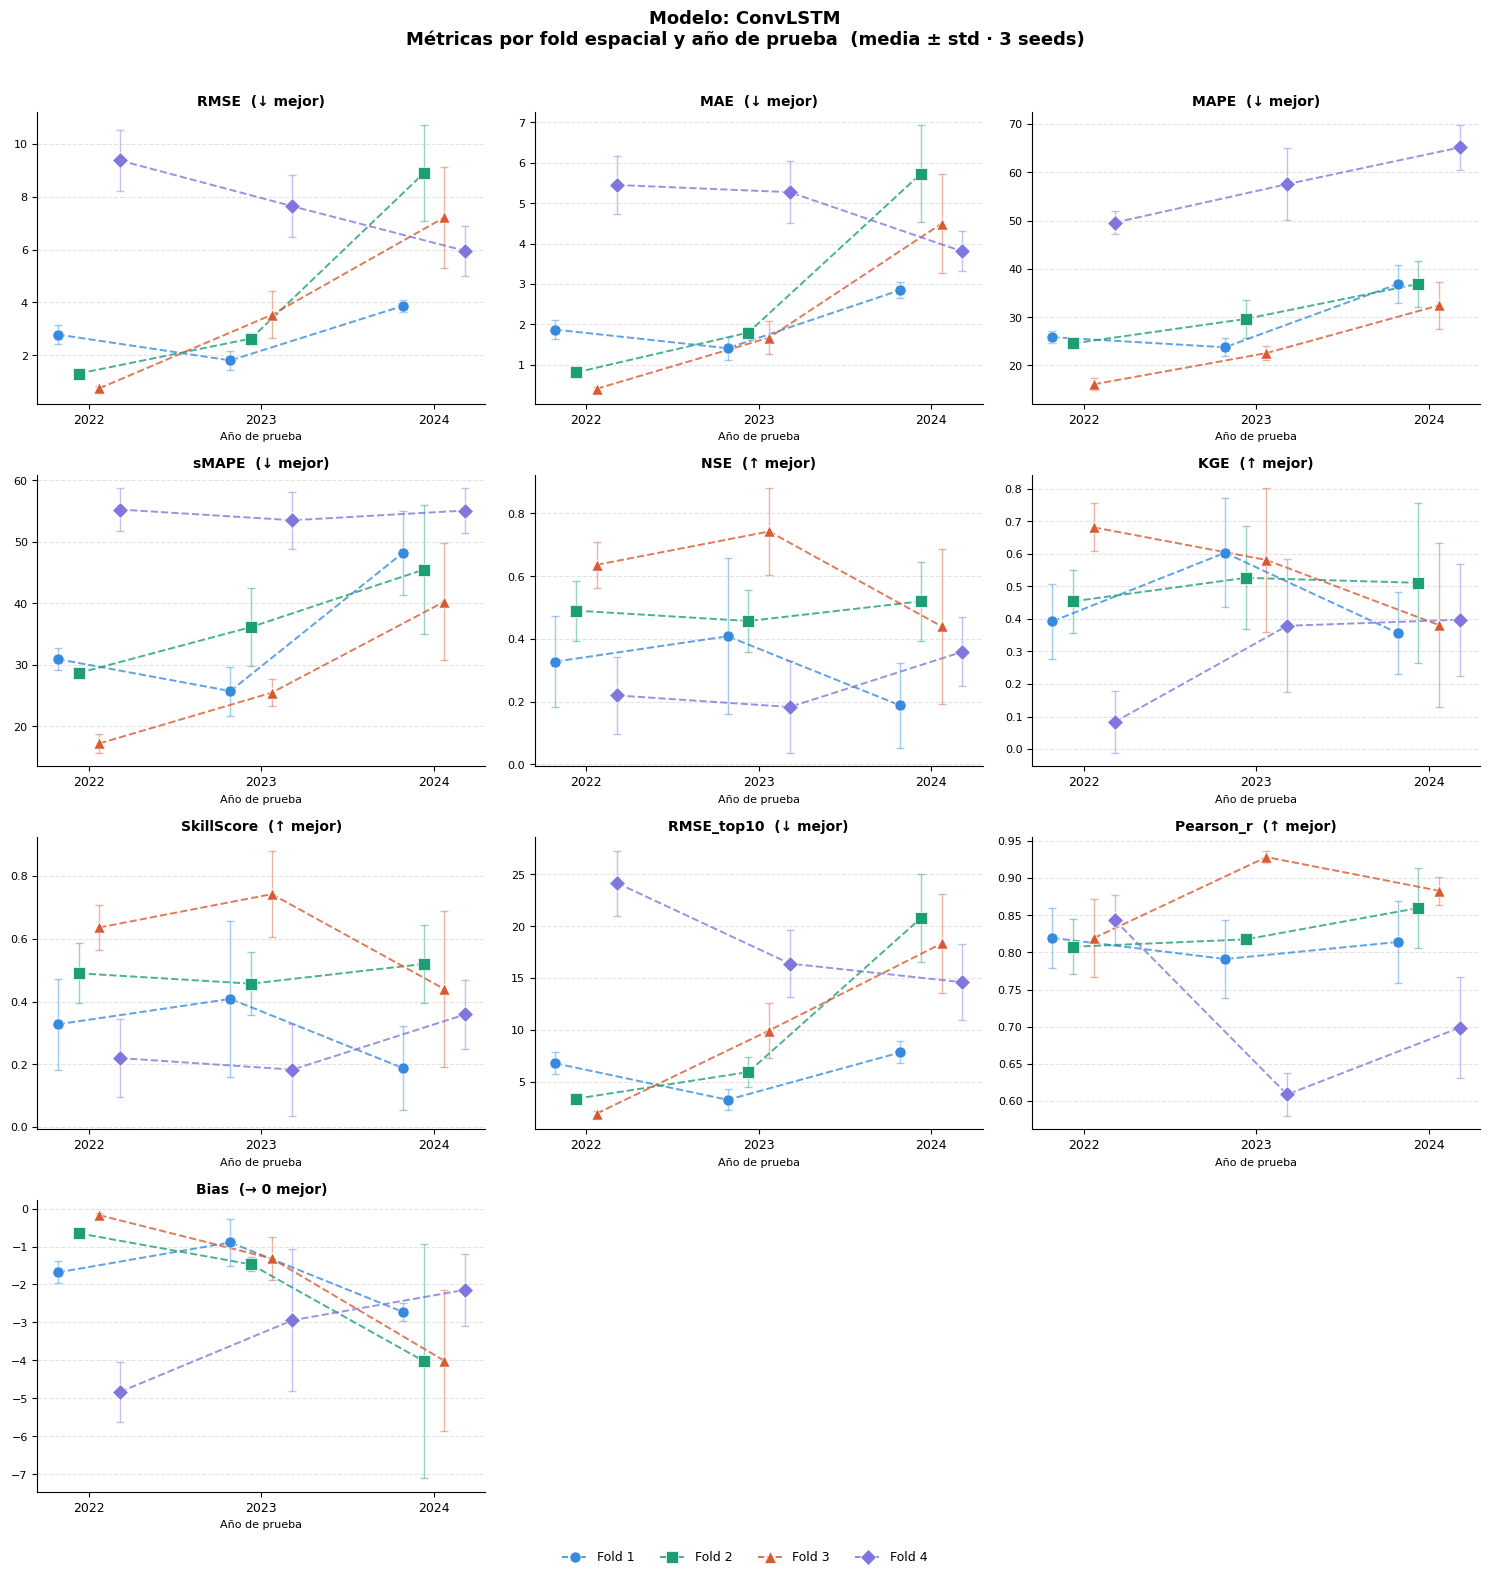

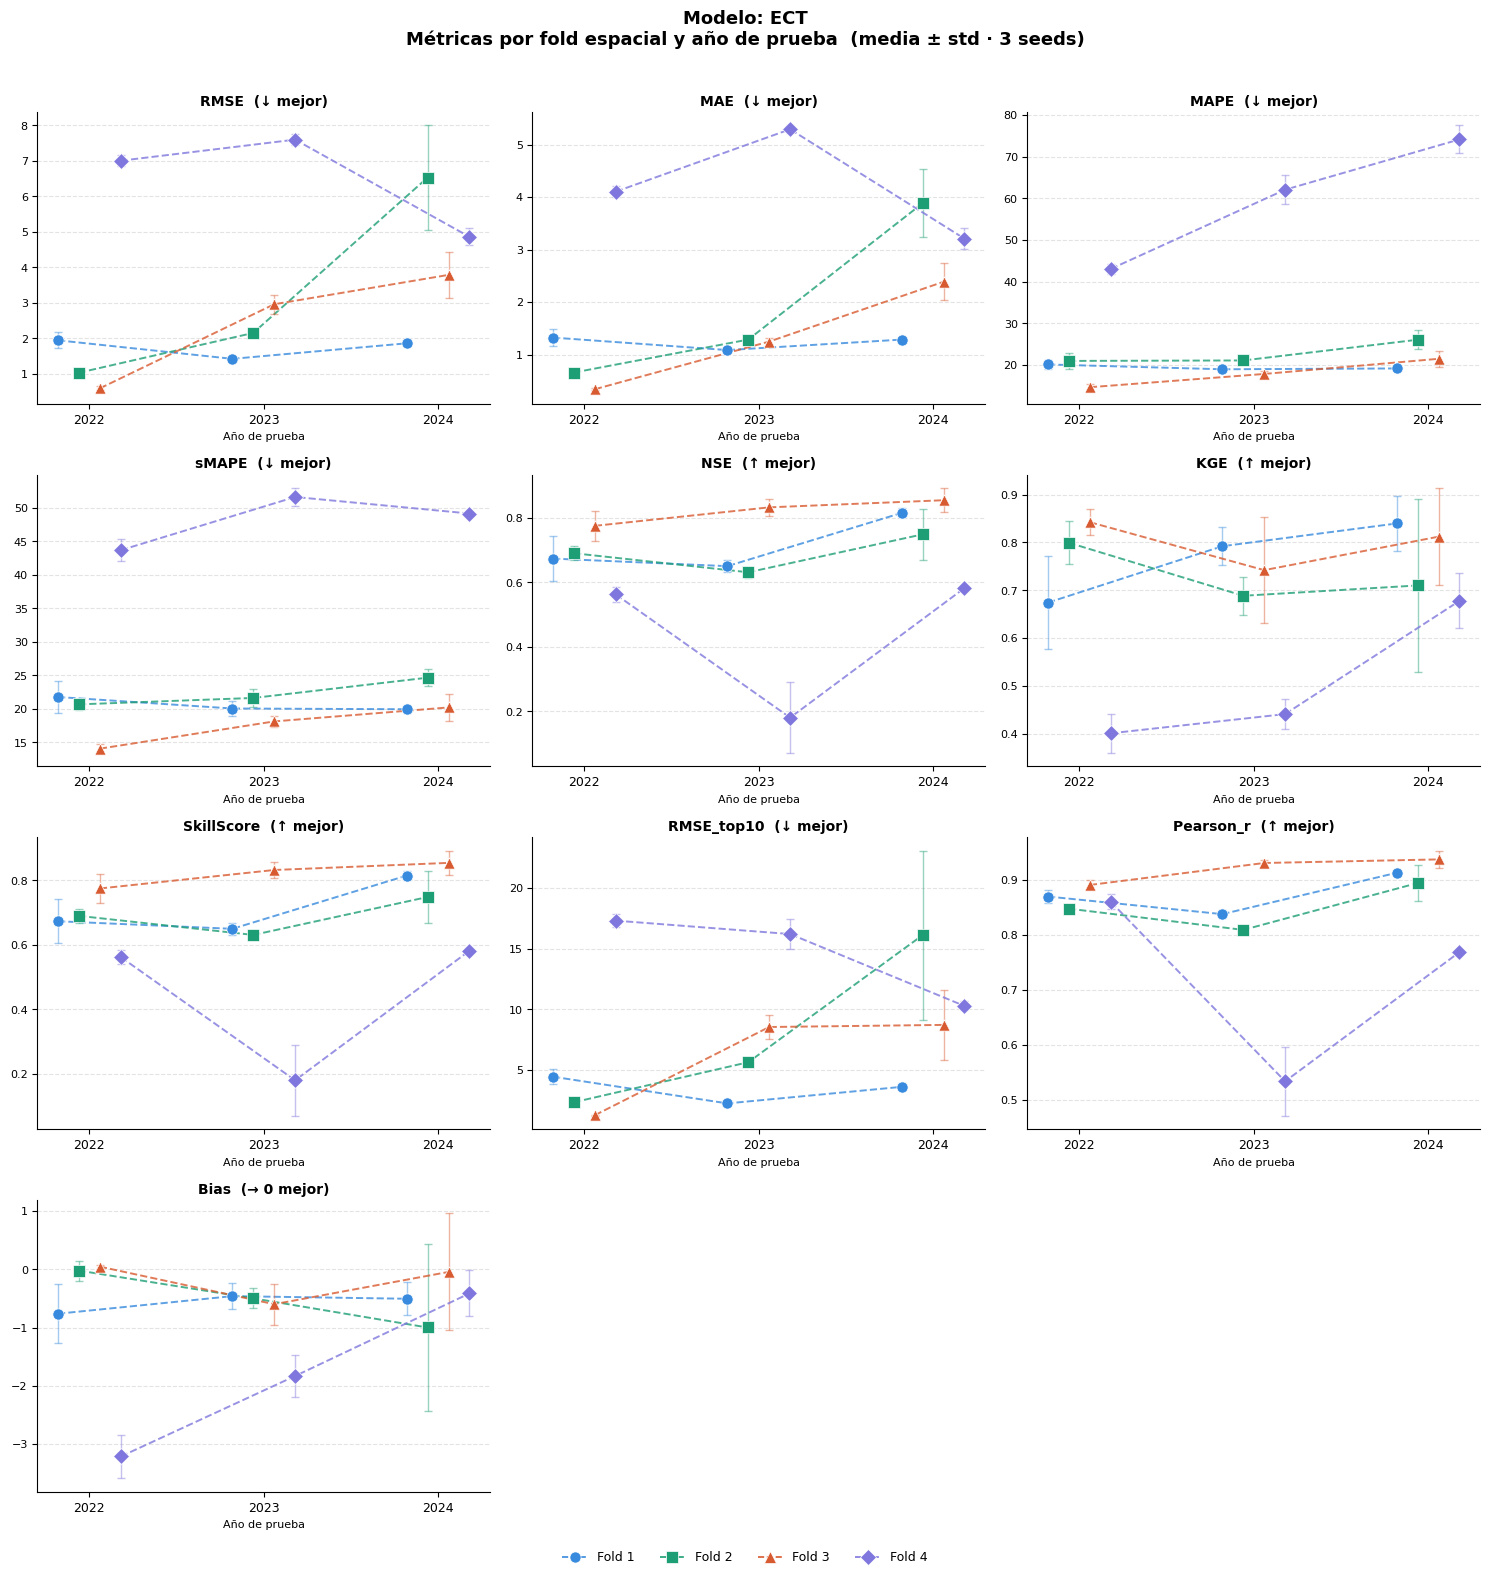

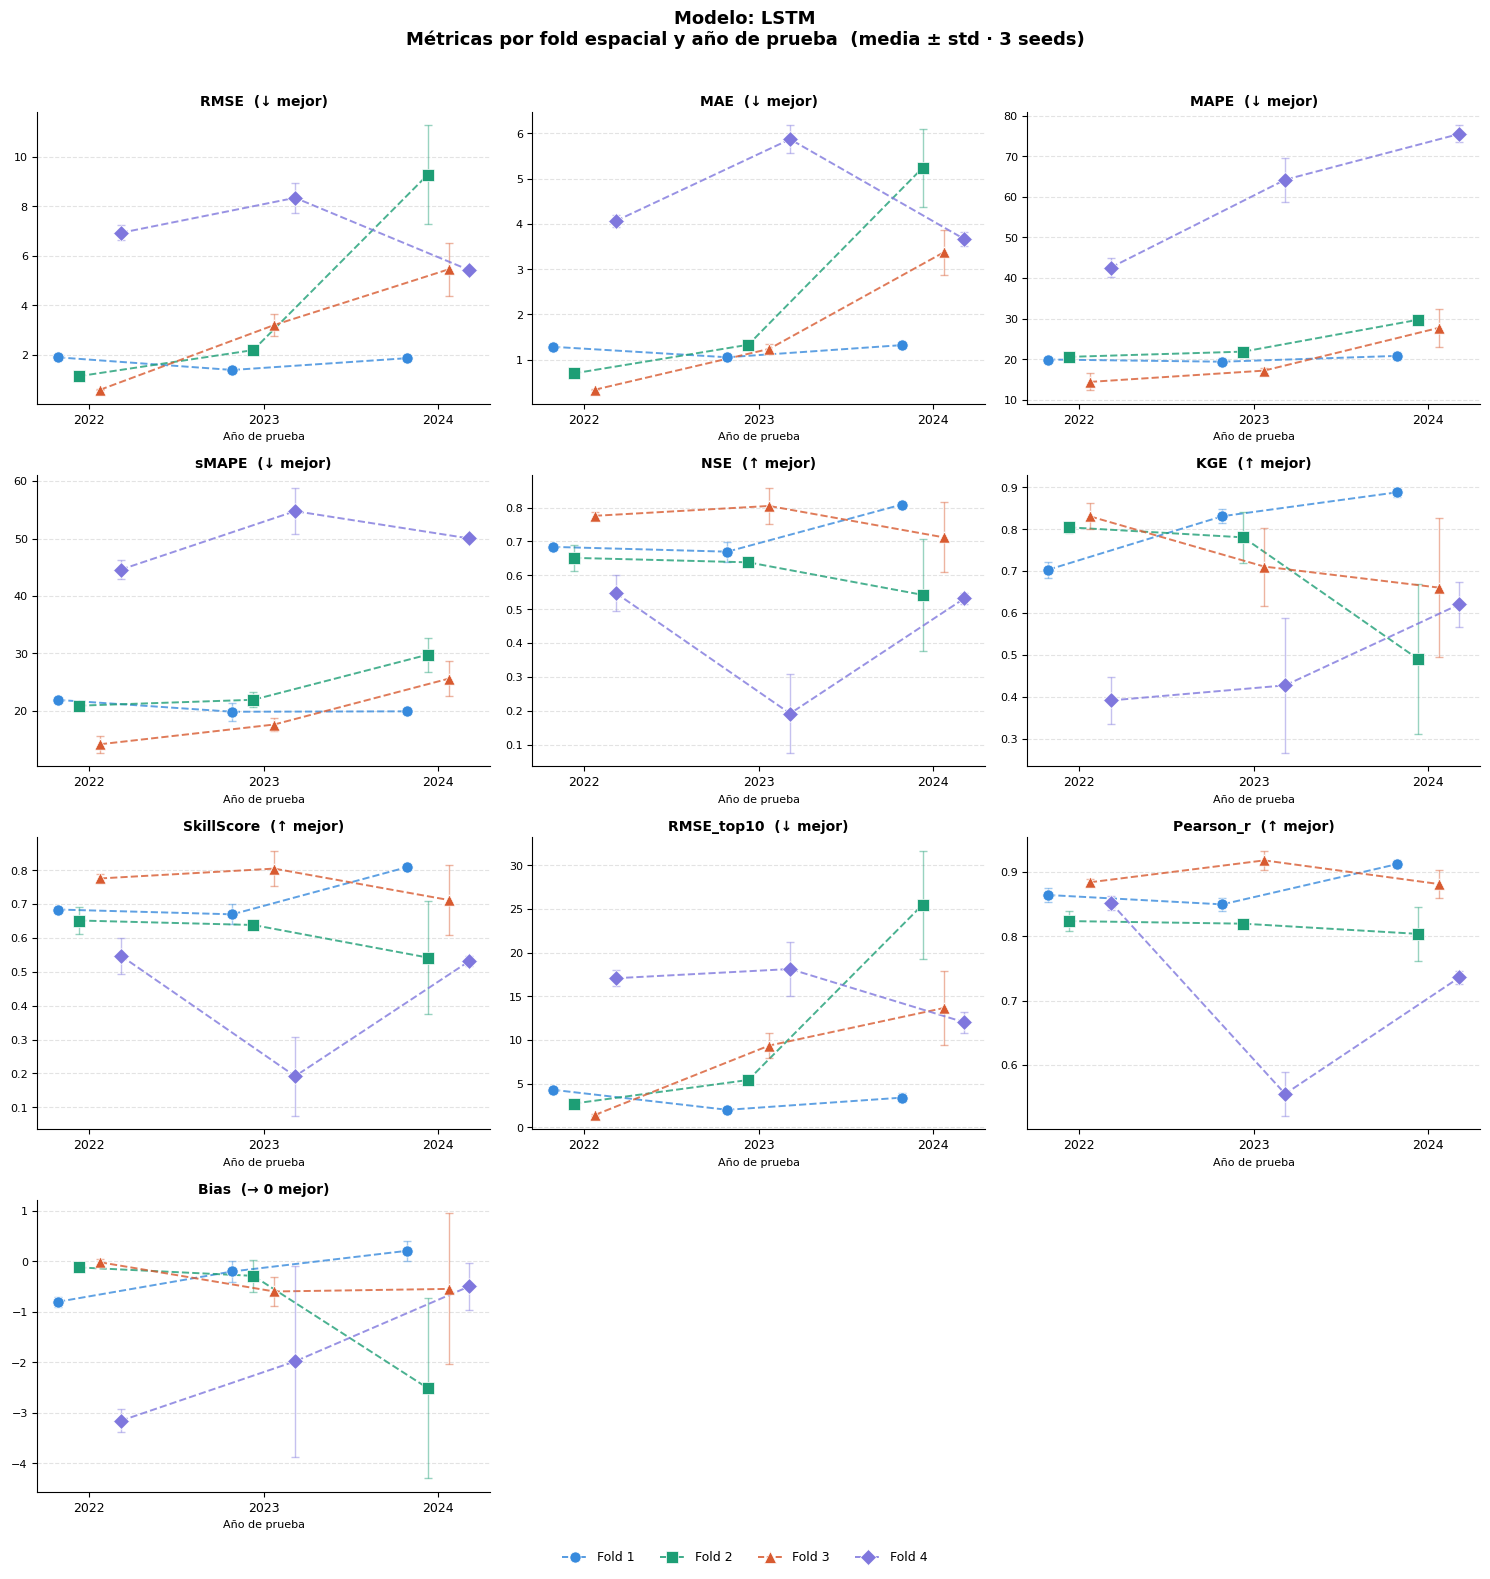

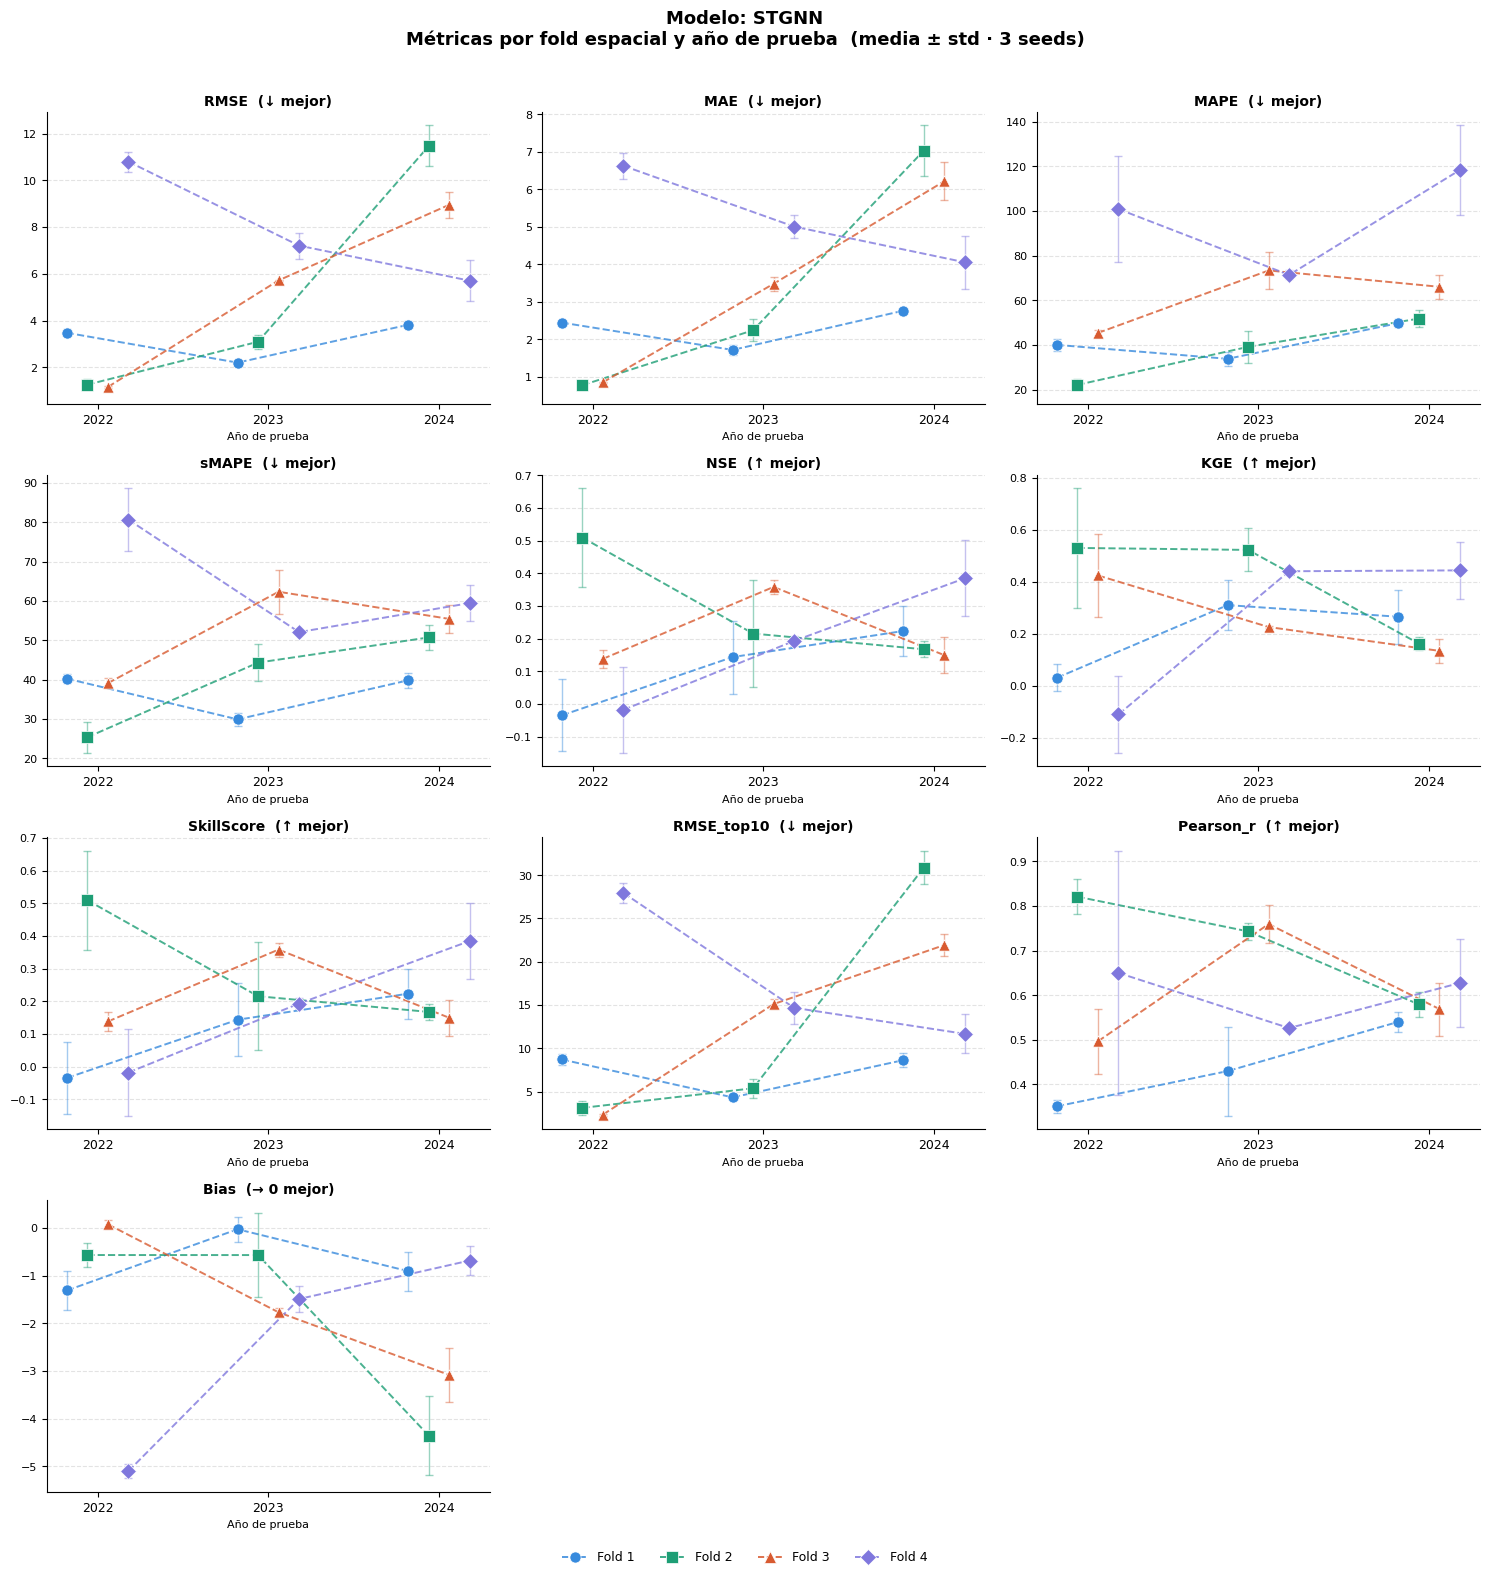

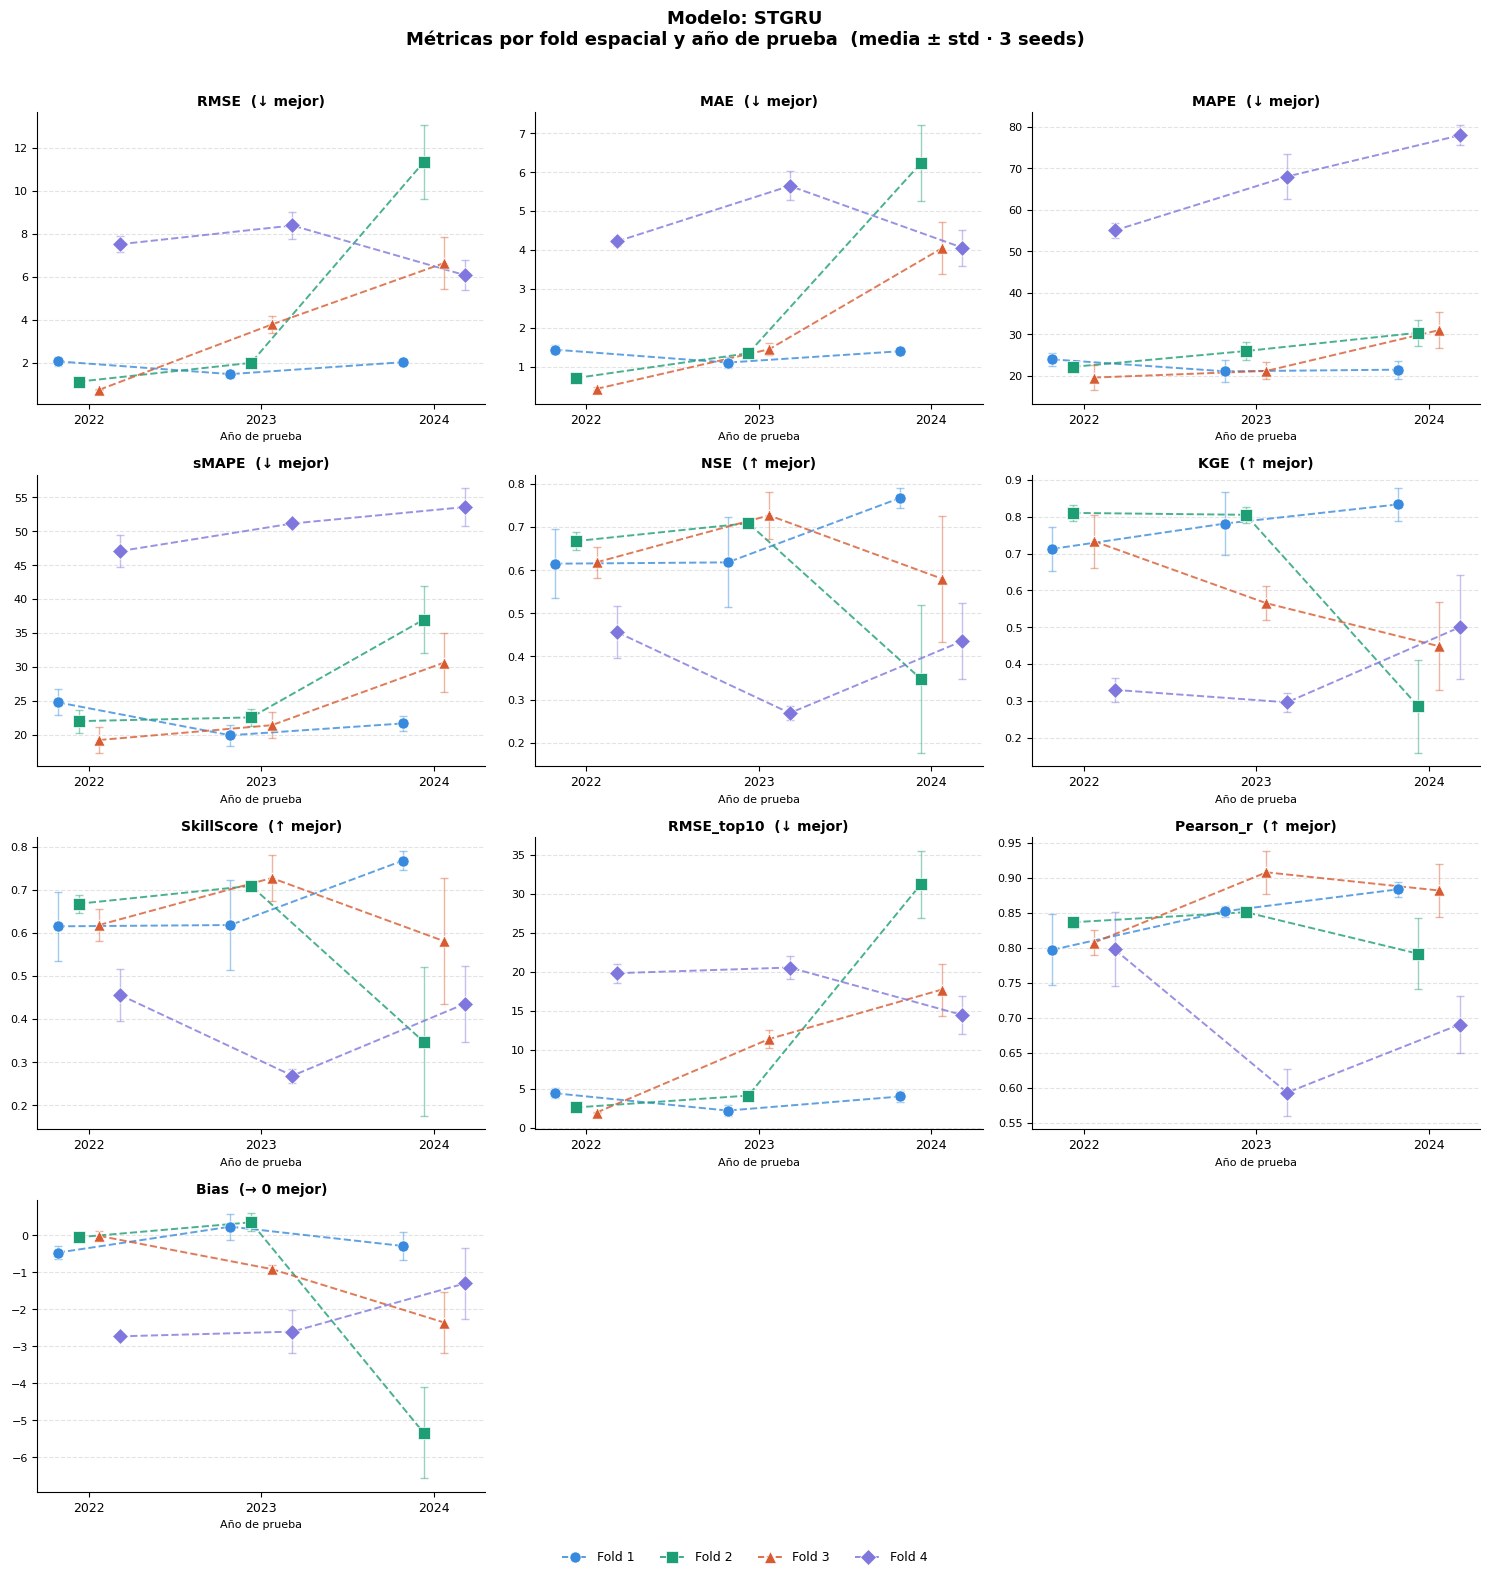

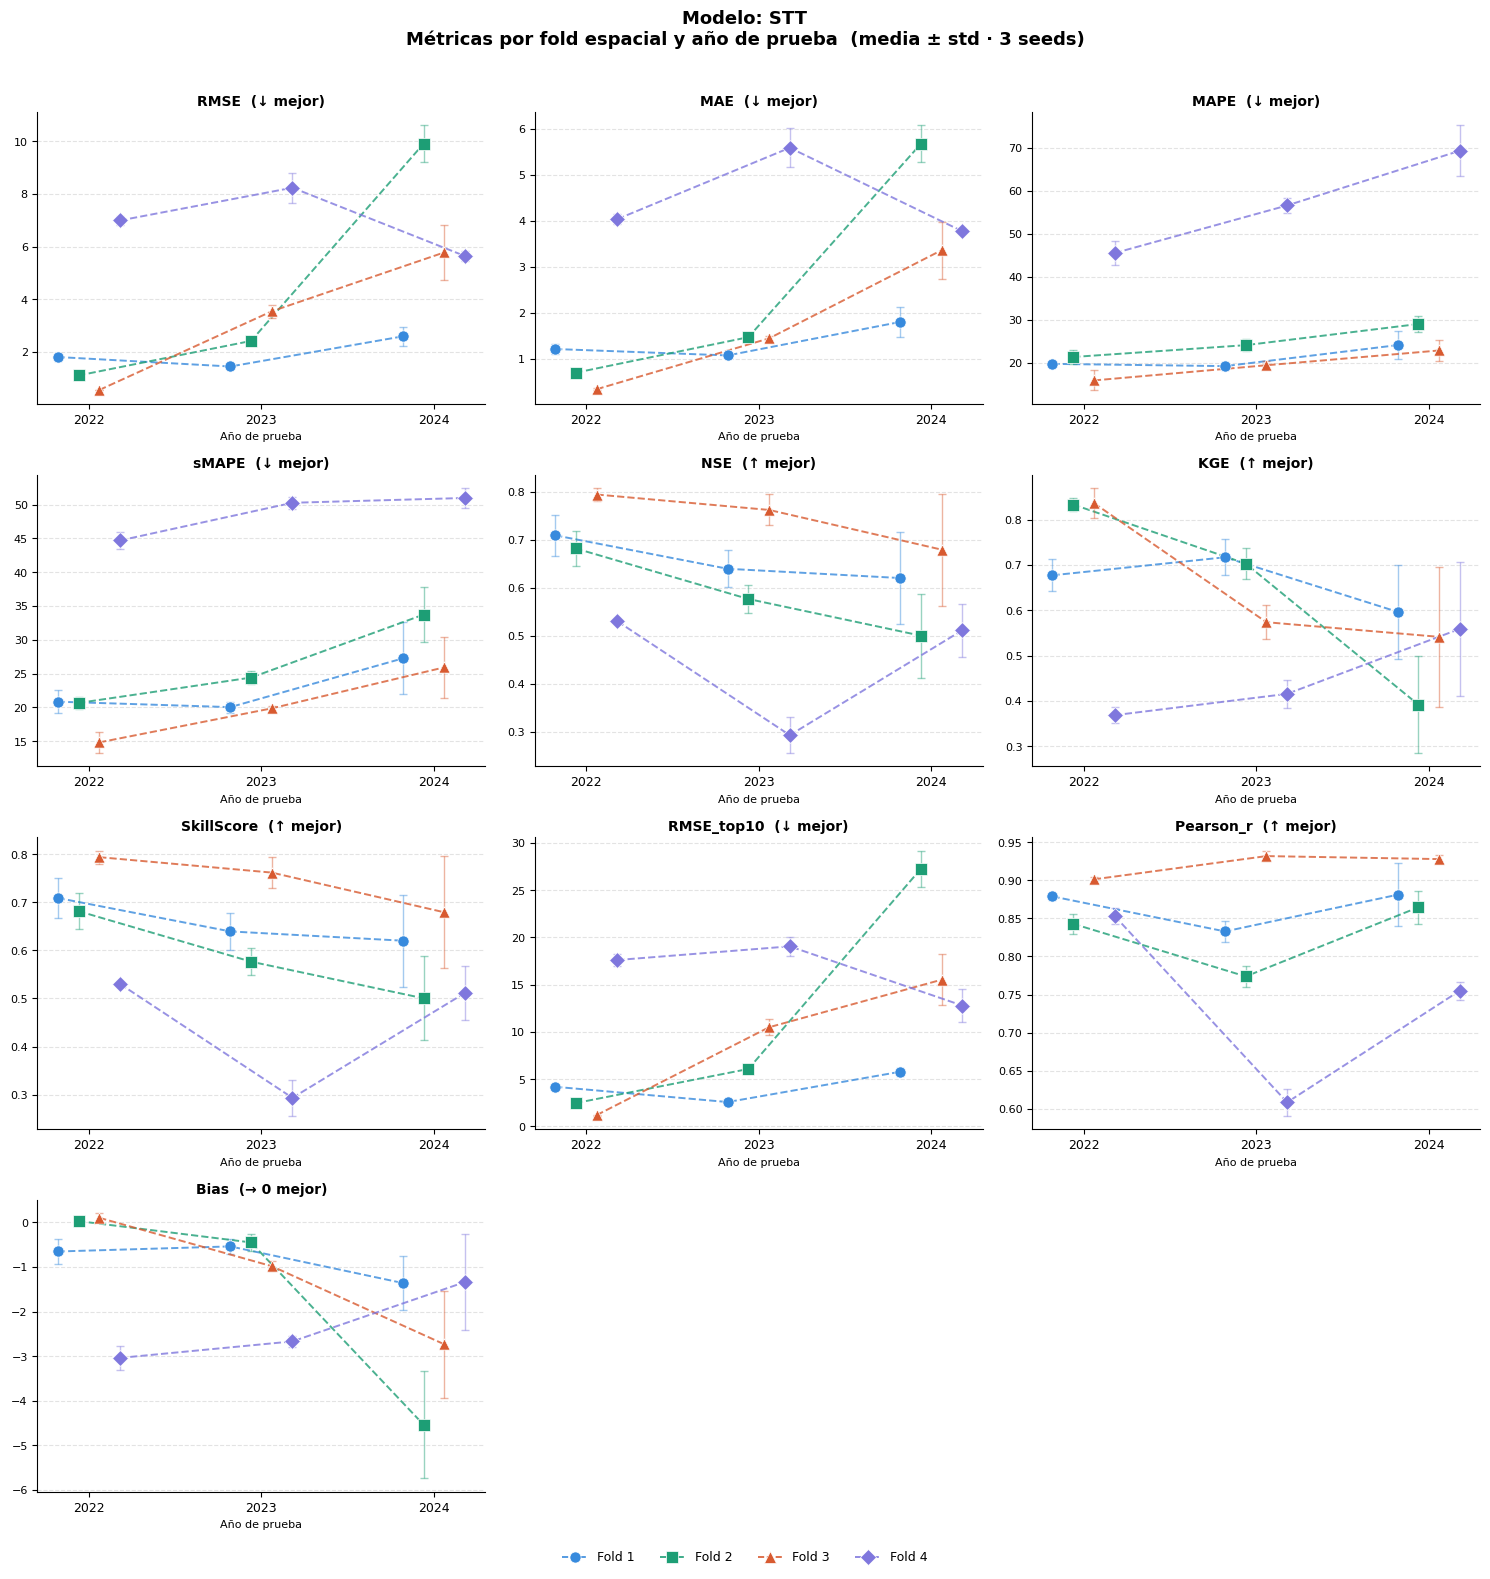

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metric_cols   = ["RMSE", "MAE", "MAPE", "sMAPE", "NSE", "KGE",
                 "SkillScore", "RMSE_top10", "Pearson_r", "Bias"]
lower_better  = {"RMSE", "MAE", "MAPE", "sMAPE", "RMSE_top10"}
higher_better = {"NSE", "KGE", "SkillScore", "Pearson_r"}

models  = sorted(summary_spatial["Model"].unique())
years   = sorted(summary_spatial["test_year"].unique())
folds   = sorted(summary_spatial["spatial_fold"].unique())

fold_colors  = {1: "#378ADD", 2: "#1D9E75", 3: "#D85A30", 4: "#7F77DD", 5: "#BA7517"}
fold_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

x      = np.arange(len(years))
width  = 0.12
n_fold = len(folds)
offsets= np.linspace(-(n_fold-1)/2, (n_fold-1)/2, n_fold) * width

n_metric_cols = 3
n_metric_rows = (len(metric_cols) + n_metric_cols - 1) // n_metric_cols

for model in models:
    df_mod = summary_spatial[summary_spatial["Model"] == model]
    model_label = model.replace("_CV", "")

    fig, axes = plt.subplots(n_metric_rows, n_metric_cols,
                              figsize=(15, n_metric_rows * 3.8))
    axes = axes.flatten()

    for i, metric in enumerate(metric_cols):
        ax = axes[i]
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        for k, fold in enumerate(folds):
            df_f = df_mod[df_mod["spatial_fold"] == fold].sort_values("test_year")
            if df_f.empty:
                continue

            y_vals = df_f[mean_col].values
            y_stds = df_f[std_col].values
            x_pos  = x + offsets[k]

            ax.plot(x_pos, y_vals,
                    color=fold_colors[fold], alpha=0.8,
                    linewidth=1.4, linestyle="--", zorder=3)
            ax.scatter(x_pos, y_vals,
                       color=fold_colors[fold],
                       marker=fold_markers[fold],
                       s=65, zorder=4, edgecolors="white", linewidths=0.5)
            ax.errorbar(x_pos, y_vals, yerr=y_stds,
                        fmt="none", color=fold_colors[fold],
                        alpha=0.45, capsize=3, linewidth=1.0, zorder=3)

        direction = ("↓ mejor" if metric in lower_better
                     else "↑ mejor" if metric in higher_better
                     else "→ 0 mejor")
        ax.set_title(f"{metric}  ({direction})", fontsize=10,
                     fontweight="bold", pad=5)
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years], fontsize=9)
        ax.tick_params(axis="y", labelsize=8)
        ax.set_xlabel("Año de prueba", fontsize=8)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    for k in range(i + 1, len(axes)):
        axes[k].set_visible(False)

    # Leyenda: un handle por fold espacial
    fold_handles = [
        plt.Line2D([0], [0], marker=fold_markers[f], color=fold_colors[f],
                   linestyle="--", markersize=8, linewidth=1.2,
                   markeredgecolor="white", markeredgewidth=0.5,
                   label=f"Fold {f}")
        for f in folds
    ]
    fig.legend(handles=fold_handles, loc="lower center",
               ncol=len(folds), fontsize=9,
               frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f"Modelo: {model_label}\n"
                 f"Métricas por fold espacial y año de prueba  "
                 f"(media ± std · 3 seeds)",
                 fontsize=13, fontweight="bold", y=1.01)

    plt.tight_layout()
    fname = f"comparacion_spatial_{model_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

La incorporación del **ECT** en el análisis por fold espacial y año de prueba revela de forma
contundente por qué este modelo lidera el ranking global: su ventaja no se concentra en un
fold o año particular, sino que se distribuye de manera estructural a través de todas las
regiones y periodos evaluados, aunque con matices importantes que vale la pena examinar
en detalle.

**En el Fold 3 (región Andina-Pacífica interior)**, donde todos los modelos alcanzan su mejor
desempeño, el ECT no solo confirma esa tendencia sino que la amplifica. Mientras LSTM, STT y
STGRU obtienen NSE entre 0.65 y 0.80 y KGE entre 0.65 y 0.85 en este fold, el ECT alcanza
valores de NSE cercanos a 0.80–0.85 y KGE sostenidamente por encima de 0.80, con una
Pearson_r que supera 0.90 en 2023 y 2024. Esto significa que en la región con mayor densidad
de datos y patrones más aprendibles, el ECT extrae mayor información predictiva que cualquier
otro modelo. Su RMSE_top10 en este fold es también el más bajo, indicando una gestión superior
de los eventos extremos en la zona Andina, precisamente donde ocurren las crecidas más
impactantes desde el punto de vista socioeconómico.

**En el Fold 1 (Costa Caribe)**, la ventaja del ECT es igualmente clara pero más moderada.
El NSE y el Skill Score del ECT se mantienen en rangos de 0.65–0.80 a lo largo de los tres
años, mientras que LSTM y STT oscilan entre 0.55 y 0.80 con mayor variabilidad. Lo más
relevante en este fold es el comportamiento del Bias: el ECT mantiene valores negativos pero
contenidos (cercanos a −0.5 o menos en magnitud), mientras que ConvLSTM acumula sesgos que
superan −2.5 en 2024 y STGNN muestra inestabilidad marcada. El STT compite de cerca con el
ECT en este fold, especialmente en Pearson_r, pero el ECT conserva una ventaja en las métricas
de ajuste global.

**En el Fold 2 (región Suroccidental: Caquetá, Cauca, Huila, Nariño y Putumayo)**, donde
todos los modelos experimentan el mayor deterioro en 2024, el ECT muestra una resiliencia
relativa notable. Mientras el RMSE_top10 de LSTM, STT y STGRU escala hasta valores de 25–28
en 2024, el ECT lo contiene por debajo de 20, y su NSE en 2024, aunque cae respecto a años
anteriores, se mantiene por encima de 0.45, nivel que ningún otro modelo logra sostener
consistentemente en este fold durante ese año. Esta capacidad de amortiguación ante el
deterioro interanual es una de las características más valiosas del ECT desde una perspectiva
operativa, pues sugiere una mejor representación de los patrones de precipitación orográfica
compleja que caracterizan esta región de transición entre los Andes y la Amazonía.

**En el Fold 4 (Amazonía: Amazonas, Guaviare y Vaupés)**, el desafío es tan extremo que
ningún modelo logra un desempeño satisfactorio, pero incluso aquí el ECT presenta diferencias
significativas respecto a sus competidores. El STGNN colapsa con MAPE cercano al 120% y NSE
negativos en 2022; ConvLSTM y STGRU acumulan los mayores sesgos negativos (por encima de
−4.5 en 2024); el LSTM y STT, aunque más estables, siguen mostrando NSE por debajo de 0.20
y alta inestabilidad en el RMSE_top10. El ECT, en cambio, aunque también se ve afectado
seriamente en este fold —con sMAPE cercano al 50% y KGE que cae a 0.40 en 2023—, recupera
parcialmente su desempeño en 2024, con NSE mejorando hacia 0.60 y Skill Score cercano a 0.60,
lo que contrasta favorablemente con el estancamiento o deterioro del resto. Este patrón de
recuperación en 2024 dentro del Fold 4 es exclusivo del ECT y sugiere que su arquitectura
captura mejor la señal hidrológica de cuencas amazónicas bajo condiciones climáticas cambiantes.

En términos del **comportamiento temporal dentro de cada fold**, otra ventaja estructural del
ECT emerge: mientras todos los demás modelos muestran trayectorias descendentes claras en
métricas de ajuste (NSE y KGE que caen sistemáticamente de 2022 a 2024) en los folds más
difíciles, el ECT frecuentemente presenta trayectorias estables o incluso ligeramente
ascendentes, especialmente en los Folds 1 y 3. Esto indica que el ECT no solo es más preciso
en promedio, sino que es **más robusto ante el cambio de condiciones interanuales**, una
propiedad fundamental para cualquier sistema de predicción hidrológica que deba operar bajo
escenarios de variabilidad climática creciente como el registrado en Colombia durante 2024,
posiblemente asociado a eventos de El Niño o condiciones hidrometeorológicas excepcionales.

## **13.3. Variabilidad**

In [20]:
summary = metrics_df.groupby("Model").agg({
    "real_RMSE":       ["mean", "std"],
    "real_MAE":        ["mean", "std"],
    "real_MAPE":       ["mean", "std"],
    "real_sMAPE":      ["mean", "std"],
    "real_NSE":        ["mean", "std"],
    "real_KGE":        ["mean", "std"],
    "real_SkillScore": ["mean", "std"],
    "real_RMSE_top10": ["mean", "std"],
    "real_Pearson_r":  ["mean", "std"],
    "real_Bias":       ["mean", "std"],
})

summary.columns = [
    "RMSE_mean",       "RMSE_std",
    "MAE_mean",        "MAE_std",
    "MAPE_mean",       "MAPE_std",
    "sMAPE_mean",      "sMAPE_std",
    "NSE_mean",        "NSE_std",
    "KGE_mean",        "KGE_std",
    "SkillScore_mean", "SkillScore_std",
    "RMSE_top10_mean", "RMSE_top10_std",
    "Pearson_r_mean",  "Pearson_r_std",
    "Bias_mean",       "Bias_std",
]

summary = summary.reset_index()

summary

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,sMAPE_mean,sMAPE_std,NSE_mean,...,KGE_mean,KGE_std,SkillScore_mean,SkillScore_std,RMSE_top10_mean,RMSE_top10_std,Pearson_r_mean,Pearson_r_std,Bias_mean,Bias_std
0,ConvLSTM_CV,4.636202,1.855190,2.599437,1.409271,32.681495,6.467338,36.208423,9.073284,0.508939,...,0.441295,0.199371,0.508939,0.134208,12.406406,4.402694,0.831925,0.022020,-2.012672,1.415758
1,ECT_CV,3.493858,0.972247,1.843094,0.720562,27.940706,3.556348,25.206805,1.712262,0.715975,...,0.701011,0.097740,0.715975,0.032967,9.042902,1.988841,0.863108,0.021612,-0.558152,0.366245
2,LSTM_CV,4.006884,1.562865,2.078062,1.017930,29.352710,5.769354,26.395114,2.877307,0.662708,...,0.649937,0.096306,0.662708,0.058305,10.681780,4.033553,0.832452,0.026084,-0.619172,0.510628
3,STGNN_CV,5.559846,1.898137,3.300762,1.446433,56.080748,8.044114,47.359823,4.473891,0.281682,...,0.281903,0.129163,0.281682,0.075687,14.921779,4.718982,0.602309,0.045360,-1.432944,0.831725
4,STGRU_CV,4.439299,1.877306,2.265179,1.155698,31.937389,3.579766,28.804112,3.359710,0.598854,...,0.539639,0.093427,0.598854,0.085218,12.472396,5.264752,0.817057,0.027650,-1.026121,0.960556
5,STT_CV,4.148196,1.675428,2.153214,1.106412,28.809073,3.607127,27.513179,4.630601,0.647981,...,0.571062,0.089190,0.647981,0.065939,11.415926,4.366397,0.854412,0.017004,-1.282073,1.110110


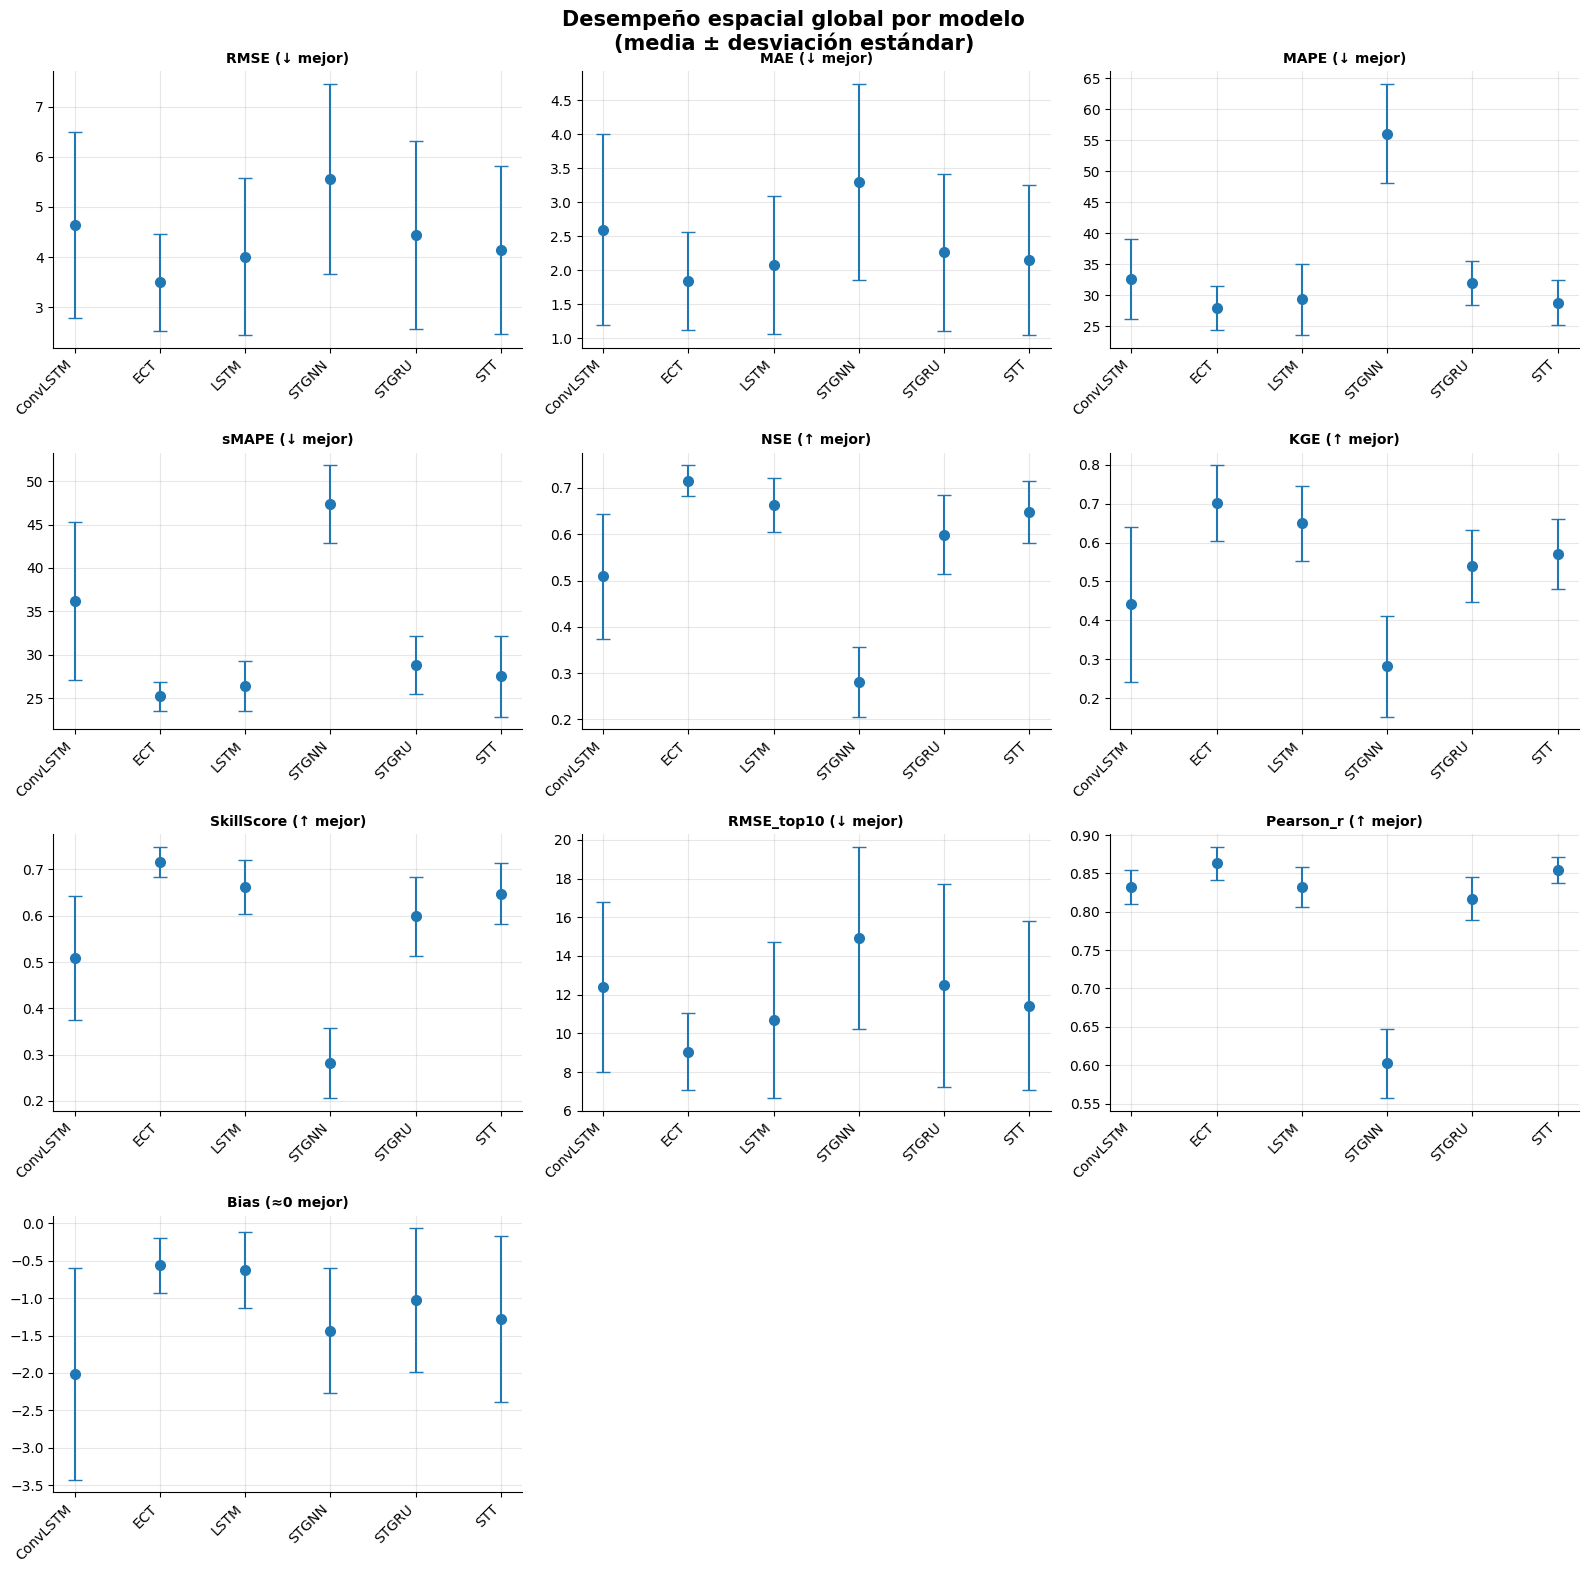

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metric_cols = [
    "RMSE", "MAE", "MAPE", "sMAPE",
    "NSE", "KGE", "SkillScore",
    "RMSE_top10", "Pearson_r", "Bias"
]

lower_better = {"RMSE", "MAE", "MAPE", "sMAPE", "RMSE_top10"}
higher_better = {"NSE", "KGE", "SkillScore", "Pearson_r"}

df = summary.copy()   

models = df["Model"].str.replace("_CV", "", regex=False)

ncols = 3
nrows = int(np.ceil(len(metric_cols) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, nrows * 4)
)

axes = axes.flatten()

for i, metric in enumerate(metric_cols):

    ax = axes[i]

    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    ax.errorbar(
        np.arange(len(models)),
        df[mean_col],
        yerr=df[std_col],
        fmt="o",
        capsize=5,
        markersize=7,
        linewidth=1.5
    )

    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")

    direction = (
        "↓ mejor" if metric in lower_better
        else "↑ mejor" if metric in higher_better
        else "≈0 mejor"
    )

    ax.set_title(
        f"{metric} ({direction})",
        fontsize=10,
        fontweight="bold"
    )

    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Desempeño espacial global por modelo\n(media ± desviación estándar)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Se observa tanto en la tabla anterior como en la figura el desempeño medio ± desviación estándar de los seis modelos evaluados
sobre las 10 métricas principales. El primer aspecto que salta a la vista es la **clara
separación entre ECT_CV y el resto de los modelos** en casi todas las métricas: no solo
registra el RMSE más bajo (3.49 ± 0.97) y el MAE más bajo (1.84 ± 0.72), sino que además
presenta los **intervalos de incertidumbre más estrechos** del conjunto, lo que visualmente
se traduce en barras de error notablemente más cortas que las de sus competidores —
especialmente en NSE, KGE y SkillScore, donde sus barras de error casi no se solapan con
las de los modelos de peor desempeño. Esto es especialmente relevante porque una barra de
error estrecha no solo indica precisión, sino **consistencia entre folds y semillas**, una
propiedad muy deseable en modelos que se pretenden generalizar. En el extremo opuesto,
**STGNN_CV destaca negativamente en prácticamente todos los paneles**: su MAPE medio supera
el 56% con una desviación de ±8 puntos porcentuales, su NSE apenas alcanza 0.28 y su KGE
ronda 0.28, valores que en hidrología se consideran cercanos al umbral de un modelo sin
poder predictivo real (NSE < 0.0 implica que la media observada predice mejor que el modelo).
Adicionalmente, su Pearson_r de 0.60 es el más bajo del grupo, lo que confirma que no solo
comete errores grandes en magnitud sino que tampoco captura bien la **estructura temporal y
espacial** del fenómeno. En la franja intermedia, **LSTM_CV, STT_CV y STGRU_CV compiten de
cerca**: los tres tienen RMSE entre 4.0 y 4.5 y sus barras de error se solapan
considerablemente, lo que sugiere que las diferencias entre ellos podrían no ser
estadísticamente significativas — precisamente la motivación para aplicar el Bootstrap
pareado. STT_CV merece atención especial porque, a pesar de no ser el mejor en RMSE, tiene
el **Pearson_r más alto después de ECT_CV (0.854)** y el **Bias más contenido entre los
modelos intermedios**, lo que indica que su estructura basada en atención captura bien la
forma de los hidrogramas aunque no optimice perfectamente la magnitud del error. Finalmente,
el panel de **Bias** revela que todos los modelos subestiman sistemáticamente los valores
reales (Bias < 0 en todos los casos), siendo ConvLSTM_CV el más afectado (−2.01 ± 1.42),
un comportamiento que podría estar relacionado con su dificultad para representar eventos
extremos — algo que también se refleja en su **RMSE_top10 más alto (12.41 ± 4.40)**, métrica
que mide el error exclusivamente sobre los picos más intensos del registro.

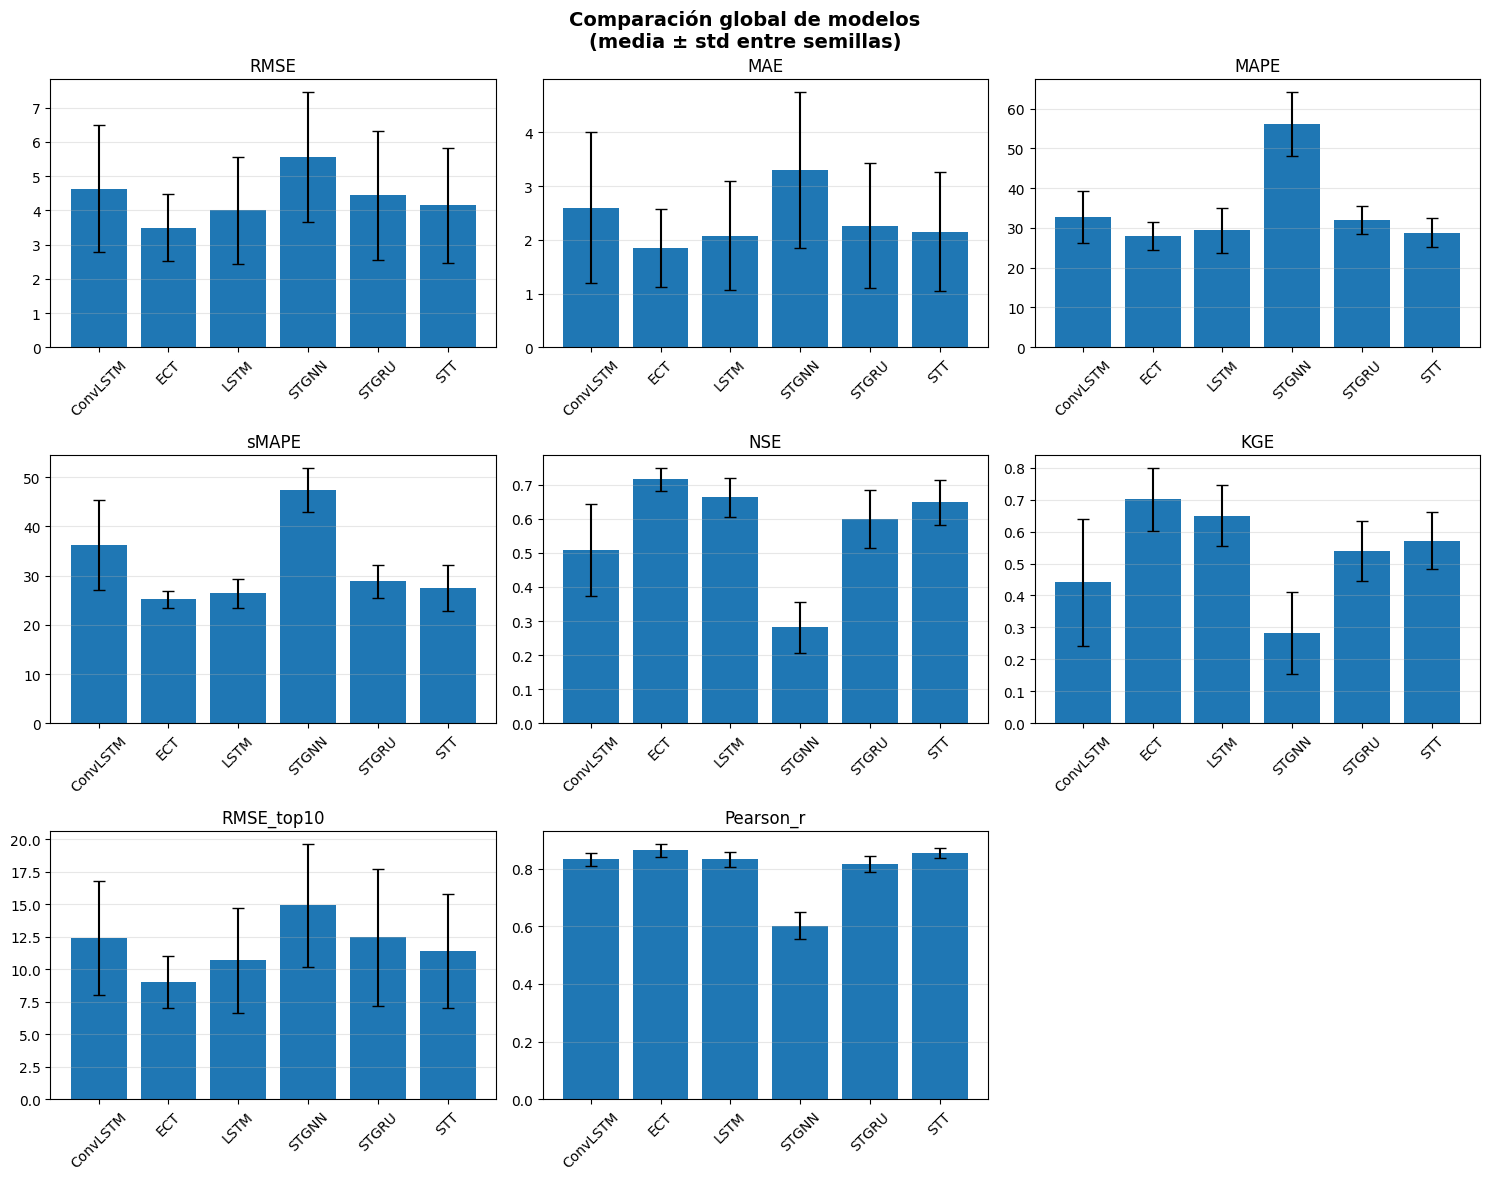

In [24]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "real_RMSE",
    "real_MAE",
    "real_MAPE",
    "real_sMAPE",
    "real_NSE",
    "real_KGE",
    "real_RMSE_top10",
    "real_Pearson_r"
]

models = sorted(metrics_global_df["Model"].unique())

ncols = 3
nrows = int(np.ceil(len(metrics)/ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, nrows*4)
)

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    summary = (
        metrics_global_df
        .groupby("Model")[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    labels = summary["Model"].str.replace("_CV","", regex=False)

    ax.bar(
        labels,
        summary["mean"],
        yerr=summary["std"],
        capsize=4
    )

    ax.set_title(metric.replace("real_",""))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Comparación global de modelos\n(media ± std entre semillas)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

La figura confirma visualmente lo observado en las tablas: **ECT_CV es el modelo de mejor
desempeño global** en prácticamente todos los paneles, con el RMSE más bajo (~3.5), el MAE
más bajo (~1.8), el NSE y KGE más altos (~0.72 y ~0.70 respectivamente), y el RMSE_top10
más bajo (~9.0), este último especialmente relevante porque indica que ECT_CV también maneja
mejor los eventos extremos. Igual de importante es que sus **barras de error son las más
cortas del conjunto** en métricas clave como NSE, KGE y MAPE, lo que refleja alta
estabilidad entre semillas. En el extremo opuesto, **STGNN_CV es claramente el peor modelo**:
sus barras son las más altas en RMSE, MAE, MAPE (~56%) y sMAPE (~47%), y las más bajas en
NSE (~0.28) y KGE (~0.28), con intervalos de error amplios que delatan inestabilidad en el
entrenamiento. Cabe destacar que en el panel de **Pearson_r STGNN_CV es el único outlier
visible**, con una correlación de ~0.60 frente a valores de 0.82–0.87 en el resto, lo que
indica que no solo comete errores grandes sino que pierde la estructura temporal de la señal.
En la franja intermedia, **LSTM_CV, STT_CV y STGRU_CV son indistinguibles visualmente** en
la mayoría de los paneles — sus barras y sus intervalos de error se solapan casi por completo
en RMSE, MAE, NSE y Pearson_r — lo que anticipa que las diferencias entre ellos
probablemente **no serán estadísticamente significativas** en el Bootstrap, y que la
comparación relevante será ECT_CV vs. ese grupo y STGNN_CV vs. todos.

In [8]:
stability = metrics_df.groupby("Model").agg({
    "real_RMSE":       "std",
    "real_MAE":        "std",
    "real_MAPE":       "std",
    "real_sMAPE":      "std",
    "real_NSE":        "std",
    "real_KGE":        "std",
    "real_SkillScore": "std",
    "real_RMSE_top10": "std",
    "real_Pearson_r":  "std",
    "real_Bias":       "std",
}).rename(columns={
    "real_RMSE":       "RMSE_variability",
    "real_MAE":        "MAE_variability",
    "real_MAPE":       "MAPE_variability",
    "real_sMAPE":      "sMAPE_variability",
    "real_NSE":        "NSE_variability",
    "real_KGE":        "KGE_variability",
    "real_SkillScore": "SkillScore_variability",
    "real_RMSE_top10": "RMSE_top10_variability",
    "real_Pearson_r":  "Pearson_r_variability",
    "real_Bias":       "Bias_variability",
})

stability

,RMSE_variability,MAE_variability,MAPE_variability,sMAPE_variability,NSE_variability,KGE_variability,SkillScore_variability,RMSE_top10_variability,Pearson_r_variability,Bias_variability
Model,,,,,,,,,,
ConvLSTM_CV,1.855190,1.409271,6.467338,9.073284,0.134208,0.199371,0.134208,4.402694,0.022020,1.415758
ECT_CV,0.972247,0.720562,3.556348,1.712262,0.032967,0.097740,0.032967,1.988841,0.021612,0.366245
LSTM_CV,1.562865,1.017930,5.769354,2.877307,0.058305,0.096306,0.058305,4.033553,0.026084,0.510628
STGNN_CV,1.898137,1.446433,8.044114,4.473891,0.075687,0.129163,0.075687,4.718982,0.045360,0.831725
STGRU_CV,1.877306,1.155698,3.579766,3.359710,0.085218,0.093427,0.085218,5.264752,0.027650,0.960556
STT_CV,1.675428,1.106412,3.607127,4.630601,0.065939,0.089190,0.065939,4.366397,0.017004,1.110110


El análisis de variabilidad entre semillas refuerza la superioridad de **ECT_CV no solo en
precisión sino en estabilidad**: registra la menor variabilidad en RMSE (0.97), MAE (0.72),
MAPE (3.56), NSE (0.033), RMSE_top10 (1.99) y Bias (0.37), lo que significa que sus
predicciones son prácticamente insensibles a la semilla de inicialización — una propiedad
crítica para un modelo que se pretende robusto y reproducible. En contraste, **ConvLSTM_CV
es el modelo más inestable del conjunto**: lidera la variabilidad en RMSE (1.86), MAE (1.41),
sMAPE (9.07) y Bias (1.42), este último especialmente preocupante porque indica que la
magnitud de la subestimación cambia drásticamente entre semillas, haciendo que sus
predicciones sean poco confiables. **STGNN_CV**, aunque no es el más variable en todas las
métricas, presenta la mayor variabilidad en MAPE (8.04) y RMSE_top10 (4.72), confirmando
que su dificultad con los eventos extremos también fluctúa según la inicialización. En el
grupo intermedio, **STT_CV destaca positivamente**: tiene la menor variabilidad en Pearson_r
(0.017) de todo el conjunto — incluso menor que ECT_CV — y valores de variabilidad en MAPE
y KGE comparables a los de ECT_CV, lo que sugiere que, aunque no es el más preciso, su
arquitectura basada en atención converge de forma consistente. **STGRU_CV**, en cambio,
presenta la mayor variabilidad en RMSE_top10 (5.26) y Bias (0.96) dentro del grupo
intermedio, lo que indica inestabilidad particular frente a eventos extremos y en la
dirección del error.

## **13.4. Comparación estadística de modelos**

In [11]:
import pandas as pd
import numpy as np
import os

BASE = "/home/moon/DEEP/PF/PF_DG/MODELOS"
MODELOS = ["LSTM_CV", "ConvLSTM_CV", "STGNN_CV", "STGRU_CV", "STT_CV", "ECT_CV"]

datos = {}
MODELO_PREFIJO = {
    "LSTM_CV":     "lstm",
    "ConvLSTM_CV": "convlstm",
    "STGNN_CV":    "stgnn",
    "STGRU_CV":    "stgru",
    "STT_CV":      "stt",
    "ECT_CV":      "ect",
}

for m in MODELOS:
    prefijo   = MODELO_PREFIJO[m]
    path_res  = os.path.join(BASE, m, f"{prefijo}_residuals.csv")
    path_pred = os.path.join(BASE, m, f"{prefijo}_predictions.csv")
    print(f"{m}")
   
    d = {}
    if os.path.exists(path_res):
        df = pd.read_csv(path_res)
        print(f"[{m}] residuals.csv → shape {df.shape} | cols: {list(df.columns)}")
        col = next((c for c in df.columns if "resid" in c.lower()), df.select_dtypes(include=np.number).columns[0])
        d["residuos"] = df[col].dropna().values
    else:
        print(f"[{m}]  residuals.csv NO encontrado")

    if os.path.exists(path_pred):
        df = pd.read_csv(path_pred)
        print(f"[{m}] predictions.csv → shape {df.shape} | cols: {list(df.columns)}")
        col_pred = next((c for c in df.columns if "pred" in c.lower()), None)
        col_real = next((c for c in df.columns if any(k in c.lower() for k in ["real","true","obs","actual","target"])), None)
        if col_pred: d["y_pred"] = df[col_pred].dropna().values
        if col_real: d["y_true"] = df[col_real].dropna().values
    else:
        print(f"[{m}]  predictions.csv NO encontrado")

    if "y_true" not in d and "y_pred" in d and "residuos" in d:
        n = min(len(d["y_pred"]), len(d["residuos"]))
        d["y_true"] = d["y_pred"][:n] + d["residuos"][:n]
        print(f"[{m}] y_true reconstruido desde pred + residuos")

    datos[m] = d
    print()

LSTM_CV
[LSTM_CV] residuals.csv → shape (43776, 8) | cols: ['seed', 'outer_fold', 'test_year', 'departamento', 'spatial_fold', 'fecha_base', 'horizonte', 'residual']
[LSTM_CV] predictions.csv → shape (43776, 14) | cols: ['seed', 'outer_fold', 'test_year', 'departamento', 'spatial_fold', 'fecha_base', 'horizonte', 'y_true_log', 'y_pred_log', 'y_true_real', 'y_pred_real', 'residual', 'abs_error', 'sq_error']

ConvLSTM_CV
[ConvLSTM_CV] residuals.csv → shape (40704, 8) | cols: ['seed', 'outer_fold', 'test_year', 'departamento', 'spatial_fold', 'fecha_base', 'horizonte', 'residual']
[ConvLSTM_CV] predictions.csv → shape (40704, 14) | cols: ['seed', 'outer_fold', 'test_year', 'departamento', 'spatial_fold', 'fecha_base', 'horizonte', 'y_true_log', 'y_pred_log', 'y_true_real', 'y_pred_real', 'residual', 'abs_error', 'sq_error']

STGNN_CV
[STGNN_CV] residuals.csv → shape (39168, 8) | cols: ['seed', 'outer_fold', 'test_year', 'departamento', 'spatial_fold', 'fecha_base', 'horizonte', 'residual'

In [32]:
from itertools import combinations

def bootstrap_pareado(y_true_a, y_pred_a, y_true_b, y_pred_b,
                      metrica="MAE", B=10_000, alpha=0.05, seed=42):
    np.random.seed(seed)
    n = min(len(y_true_a), len(y_true_b))

    ya_t, ya_p = y_true_a[:n], y_pred_a[:n]
    yb_t, yb_p = y_true_b[:n], y_pred_b[:n]

    def calc(yt, yp):
        e = np.abs(yt - yp)
        if metrica == "MAE":   return np.mean(e)
        if metrica == "RMSE":  return np.sqrt(np.mean((yt - yp)**2))
        if metrica == "MAPE":
            mask = yt != 0
            return np.mean(e[mask] / np.abs(yt[mask])) * 100
        if metrica == "NSE":
            return 1 - np.sum((yt-yp)**2) / np.sum((yt - np.mean(yt))**2)

    obs_diff = calc(ya_t, ya_p) - calc(yb_t, yb_p)

    boot = np.array([
        calc(ya_t[idx := np.random.randint(0, n, n)], ya_p[idx]) -
        calc(yb_t[idx], yb_p[idx])
        for _ in range(B)
    ])

    p_val = np.mean(np.abs(boot - boot.mean()) >= np.abs(obs_diff))
    ci = (np.percentile(boot, 100*alpha/2), np.percentile(boot, 100*(1-alpha/2)))

    return {"diff": obs_diff, "p_value": p_val,
            "ci_low": ci[0], "ci_high": ci[1],
            "sig": p_val < alpha, "B": B, "n": n}


n_min = min(
    min(len(d.get("y_true", [])), len(d.get("y_pred", [])))
    for d in datos.values()
    if "y_true" in d and "y_pred" in d
)
print(f"n alineado = {n_min} observaciones por modelo\n")

METRICA = "RMSE"   
B       = 10_000

print(f"Bootstrap pareado | Métrica: {METRICA} | B={B:,}")
print("=" * 65)

modelos_validos = [m for m in MODELOS if "y_true" in datos[m] and "y_pred" in datos[m]]
filas = []

for m_a, m_b in combinations(modelos_validos, 2):
    res = bootstrap_pareado(
        datos[m_a]["y_true"], datos[m_a]["y_pred"],
        datos[m_b]["y_true"], datos[m_b]["y_pred"],
        metrica=METRICA, B=B
    )
    sig = " SÍ" if res["sig"] else " NO"
    print(f"  {m_a:15s} vs {m_b:15s} | "
          f"Δ={res['diff']:+.4f} | "
          f"IC=[{res['ci_low']:.4f},{res['ci_high']:.4f}] | "
          f"p={res['p_value']:.4f} | {sig}")
    filas.append({
        "Modelo A": m_a, "Modelo B": m_b,
        f"Δ {METRICA}": round(res["diff"], 5),
        "IC 95% Low": round(res["ci_low"], 5),
        "IC 95% High": round(res["ci_high"], 5),
        "p-value": round(res["p_value"], 4),
        "Significativo": "Sí" if res["sig"] else "No"
    })

df_boot = pd.DataFrame(filas)
print("\n")
df_boot

n alineado = 39168 observaciones por modelo

Bootstrap pareado | Métrica: RMSE | B=10,000
  LSTM_CV         vs ConvLSTM_CV     | Δ=-0.1243 | IC=[-0.1306,-0.1180] | p=0.0000 |  SÍ
  LSTM_CV         vs STGNN_CV        | Δ=-0.2498 | IC=[-0.2564,-0.2434] | p=0.0000 |  SÍ
  LSTM_CV         vs STGRU_CV        | Δ=-0.0127 | IC=[-0.0178,-0.0075] | p=0.0000 |  SÍ
  LSTM_CV         vs STT_CV          | Δ=+0.0003 | IC=[-0.0046,0.0053] | p=0.9055 |  NO
  LSTM_CV         vs ECT_CV          | Δ=+0.0140 | IC=[0.0079,0.0200] | p=0.0000 |  SÍ
  ConvLSTM_CV     vs STGNN_CV        | Δ=-0.1266 | IC=[-0.1325,-0.1208] | p=0.0000 |  SÍ
  ConvLSTM_CV     vs STGRU_CV        | Δ=+0.1118 | IC=[0.1058,0.1179] | p=0.0000 |  SÍ
  ConvLSTM_CV     vs STT_CV          | Δ=+0.1317 | IC=[0.1255,0.1380] | p=0.0000 |  SÍ
  ConvLSTM_CV     vs ECT_CV          | Δ=+0.1383 | IC=[0.1329,0.1436] | p=0.0000 |  SÍ
  STGNN_CV        vs STGRU_CV        | Δ=+0.2357 | IC=[0.2296,0.2421] | p=0.0000 |  SÍ
  STGNN_CV        vs STT_CV    

,Modelo A,Modelo B,Δ RMSE,IC 95% Low,IC 95% High,p-value,Significativo
0,LSTM_CV,ConvLSTM_CV,-0.12425,-0.13059,-0.11800,0.0000,Sí
1,LSTM_CV,STGNN_CV,-0.24982,-0.25641,-0.24344,0.0000,Sí
2,LSTM_CV,STGRU_CV,-0.01267,-0.01782,-0.00748,0.0000,Sí
3,LSTM_CV,STT_CV,0.00032,-0.00460,0.00526,0.9055,No
4,LSTM_CV,ECT_CV,0.01401,0.00787,0.01997,0.0000,Sí
5,ConvLSTM_CV,STGNN_CV,-0.12659,-0.13247,-0.12078,0.0000,Sí
6,ConvLSTM_CV,STGRU_CV,0.11183,0.10579,0.11786,0.0000,Sí
7,ConvLSTM_CV,STT_CV,0.13174,0.12545,0.13796,0.0000,Sí
8,ConvLSTM_CV,ECT_CV,0.13826,0.13290,0.14359,0.0000,Sí
9,STGNN_CV,STGRU_CV,0.23572,0.22960,0.24207,0.0000,Sí


Los resultados del Bootstrap pareado sobre RMSE muestran un hallazgo particularmente relevante: **14 de los 15 pares son
estadísticamente significativos**, pero el par **LSTM_CV vs STT_CV no lo es**
(Δ = +0.0003, IC: [−0.005, +0.005], p = 0.906), lo que indica que en términos de RMSE
estos dos modelos son prácticamente equivalentes y su diferencia observada es
indistinguible del ruido muestral. Este es el único caso donde el Bootstrap no permite
establecer una jerarquía clara, y tiene implicaciones prácticas: a efectos de RMSE,
LSTM_CV y STT_CV pueden considerarse modelos de desempeño equivalente. El resto de la
jerarquía se mantiene sólida: **ECT_CV sigue siendo el mejor modelo**, superando a STT_CV
por un Δ RMSE de 0.007 (p = 0.035) — significativo pero con el p-value más alto del
conjunto, lo que refleja una diferencia real pero estrecha — y a STGNN_CV por 0.263
unidades, la brecha más amplia del análisis. **STGNN_CV continúa siendo el peor modelo**
de forma contundente: su diferencia frente a ECT_CV (Δ = 0.263, IC: [0.257, 0.269]) y
frente a STT_CV (Δ = 0.257, IC: [0.250, 0.263]) tienen intervalos de confianza
completamente alejados de cero. El ranking final consolidado por RMSE es:
**ECT_CV > STT_CV ≈ LSTM_CV > STGRU_CV > ConvLSTM_CV > STGNN_CV**, donde el símbolo ≈
refleja la no significancia estadística entre STT_CV y LSTM_CV — el único par donde el
Bootstrap indica equivalencia real entre modelos.

## **13.5. Evaluando Robustez**

Para evaluar la robustez de los modelos, se analizaron las medias y desviaciones estándar de cada métrica de desempeño (RMSE, MAE y R²) a través de múltiples ejecuciones, con el fin de cuantificar tanto el rendimiento promedio como su variabilidad. Adicionalmente, se calculó el coeficiente de variación, lo que permitió estandarizar la dispersión relativa de los resultados y comparar la estabilidad entre modelos con diferentes escalas de error. Este enfoque facilita la identificación de aquellos modelos que no solo presentan buen desempeño promedio, sino también consistencia frente a variaciones en la inicialización y el proceso de entrenamiento, lo cual es fundamental para evaluar su robustez.

### **13.7.1. Medias & Desviaciones**

In [25]:
metric_cols = [
    "real_RMSE",
    "real_MAE",
    "real_MAPE",
    "real_sMAPE",
    "real_NSE",
    "real_KGE",
    "real_SkillScore",
    "real_RMSE_top10",
    "real_Pearson_r",
    "real_Bias"
]

# Desviación estándar entre semillas
std_table = (
    metrics_global_df
    .groupby("Model")[metric_cols]
    .std()
)

# Robustez normalizada
robustness = (
    std_table
    .div(std_table.max())
    .mean(axis=1)
)

robustness = robustness.sort_values()

robustness

Model
ECT_CV         0.373562
LSTM_CV        0.561525
STT_CV         0.602471
STGRU_CV       0.662993
STGNN_CV       0.775265
ConvLSTM_CV    0.907738
dtype: float64

El índice de robustez normalizada confirma
de forma cuantitativa lo observado visualmente: **ECT_CV es el modelo más robusto del
conjunto con un índice de 0.374**, es decir, su variabilidad promedio representa apenas el
37% de la variabilidad máxima observada en cada métrica, lo que significa que sus
predicciones cambian muy poco independientemente de la semilla de inicialización utilizada.
Le siguen **LSTM_CV (0.562) y STT_CV (0.602)**, ambos con niveles de robustez moderados y
relativamente cercanos entre sí, lo que sugiere que estas arquitecturas, aunque menos
estables que ECT_CV, mantienen un comportamiento razonablemente consistente entre
ejecuciones. **STGRU_CV (0.663) y STGNN_CV (0.775)** ocupan la franja de robustez baja,
con variabilidades que superan el 66% y el 77% del máximo respectivamente, indicando
sensibilidad considerable a la inicialización. En el último lugar se encuentra
**ConvLSTM_CV con un índice de 0.908** — el más alto y por tanto el menos robusto —,
lo que significa que en promedio su variabilidad entre semillas se acerca al máximo
observado en el grupo, un comportamiento que ya había sido anticipado por el colapso de
su KGE entre semillas reportado anteriormente. En síntesis, el ranking de robustez
**ECT_CV > LSTM_CV > STT_CV > STGRU_CV > STGNN_CV > ConvLSTM_CV** es consistente con
el ranking de precisión, reforzando la conclusión de que ECT_CV no solo predice mejor
sino que lo hace de manera más confiable y reproducible.

### **13.7.2. Coeficiente de Variación**

In [28]:
metric_cols = [
    "real_RMSE",
    "real_MAE",
    "real_MAPE",
    "real_sMAPE",
    "real_NSE",
    "real_KGE",
    "real_SkillScore",
    "real_RMSE_top10",
    "real_Pearson_r"
]

cv_table = (
    metrics_df
    .groupby("Model")[metric_cols]
    .std()
    .div(
        metrics_df
        .groupby("Model")[metric_cols]
        .mean()
        .abs()
    )
) * 100

cv_table.round(2)

,real_RMSE,real_MAE,real_MAPE,real_sMAPE,real_NSE,real_KGE,real_SkillScore,real_RMSE_top10,real_Pearson_r
Model,,,,,,,,,
ConvLSTM_CV,40.02,54.21,19.79,25.06,26.37,45.18,26.37,35.49,2.65
ECT_CV,27.83,39.10,12.73,6.79,4.60,13.94,4.60,21.99,2.50
LSTM_CV,39.00,48.98,19.66,10.90,8.80,14.82,8.80,37.76,3.13
STGNN_CV,34.14,43.82,14.34,9.45,26.87,45.82,26.87,31.62,7.53
STGRU_CV,42.29,51.02,11.21,11.66,14.23,17.31,14.23,42.21,3.38
STT_CV,40.39,51.38,12.52,16.83,10.18,15.62,10.18,38.25,1.99


El coeficiente de variación (CV%), que expresa la desviación estándar como porcentaje de la
media y permite comparar la dispersión relativa independientemente de la escala de cada
métrica, revela patrones importantes sobre la estabilidad de cada modelo. **ECT_CV presenta
los CV más bajos en la mayoría de las métricas críticas**: NSE (4.60%), sMAPE (6.79%),
KGE (13.94%) y MAPE (13.73%), lo que confirma cuantitativamente que es el modelo más
estable. Sin embargo, su CV en RMSE (27.83%) y MAE (39.10%) —aunque los más bajos del
grupo— siguen siendo considerables en términos absolutos, lo que refleja la variabilidad
natural introducida por los distintos años de test en la validación cruzada. **ConvLSTM_CV
es el modelo más inestable en términos relativos**: su CV en MAE alcanza 54.21%, en KGE
45.18% y en RMSE_top10 35.49%, valores que indican que su desempeño fluctúa fuertemente
entre condiciones de entrenamiento. **STGRU_CV** muestra el CV más alto en RMSE (42.29%)
y RMSE_top10 (42.21%), mientras que paradójicamente tiene el CV más bajo en MAPE (11.21%),
lo que sugiere que su error relativo porcentual es estable pero su error absoluto en
magnitud varía considerablemente. **STGNN_CV** destaca negativamente en Pearson_r (7.53%),
el más alto del grupo, confirmando que incluso su capacidad de capturar la estructura
temporal de la señal es inconsistente entre ejecuciones. Finalmente, **STT_CV** tiene el CV
más bajo en Pearson_r (1.99%) de todo el conjunto, lo que indica que su correlación con los
valores observados es extremadamente estable, aunque su variabilidad en MAE (51.38%) y
RMSE (40.39%) lo aleja de ECT_CV en términos de estabilidad general.

## **13.6. Overfitting/underfitting**

En esta sección se analiza la presencia de **sobreajuste (overfitting) y subajuste (underfitting)** en los modelos evaluados a partir de sus curvas de aprendizaje. Para ello, se utiliza la diferencia entre la pérdida de validación y la pérdida de entrenamiento como indicador del grado de generalización del modelo, calculada a nivel de épocas y posteriormente agregada por semillas y particiones. Este enfoque permite cuantificar la brecha de generalización (generalization gap) y evaluar su estabilidad mediante medidas de tendencia central y dispersión, facilitando la comparación consistente del comportamiento de cada arquitectura bajo el mismo esquema experimental.


In [30]:
import os
import pandas as pd

BASE_DIR = "/home/moon/DEEP/PF/PF_DG/MODELOS"

MODELOS = [
    "LSTM_CV",
    "ConvLSTM_CV",
    "STGNN_CV",
    "STGRU_CV",
    "STT_CV",
    "ECT_CV"
]

all_results = []

for model in MODELOS:

    model_path = os.path.join(BASE_DIR, model)

    if not os.path.isdir(model_path):
        print(f"No existe: {model_path}")
        continue

    history_files = [
        f for f in os.listdir(model_path)
        if "training_history" in f.lower()
        and f.endswith(".csv")
    ]

    if not history_files:
        print(f"No history found for {model}")
        continue

    history_path = os.path.join(model_path, history_files[0])

    history = pd.read_csv(history_path)

    summary_gap = (
        history
        .groupby(["seed", "outer_fold"])
        .agg({
            "train_loss": "last",
            "val_loss": "last"
        })
        .reset_index()
    )

    summary_gap["gap"] = (
        summary_gap["val_loss"]
        - summary_gap["train_loss"]
    )

    model_summary = pd.DataFrame({
        "Model": [model],
        "gap_mean": [summary_gap["gap"].mean()],
        "gap_std": [summary_gap["gap"].std()],
        "gap_min": [summary_gap["gap"].min()],
        "gap_max": [summary_gap["gap"].max()],
        "n_runs": [len(summary_gap)]
    })

    all_results.append(model_summary)

final_overfit = (
    pd.concat(all_results, ignore_index=True)
    .sort_values("gap_mean")
)

final_overfit

,Model,gap_mean,gap_std,gap_min,gap_max,n_runs
1,ConvLSTM_CV,-0.042417,0.068906,-0.164866,0.073672,9
4,STT_CV,-0.006978,0.031945,-0.043486,0.055296,9
5,ECT_CV,-0.001895,0.036491,-0.049714,0.061982,9
3,STGRU_CV,0.030101,0.023651,-0.005306,0.067292,9
0,LSTM_CV,0.030952,0.034614,-0.028210,0.082193,9
2,STGNN_CV,0.108923,0.110990,-0.049928,0.263282,9


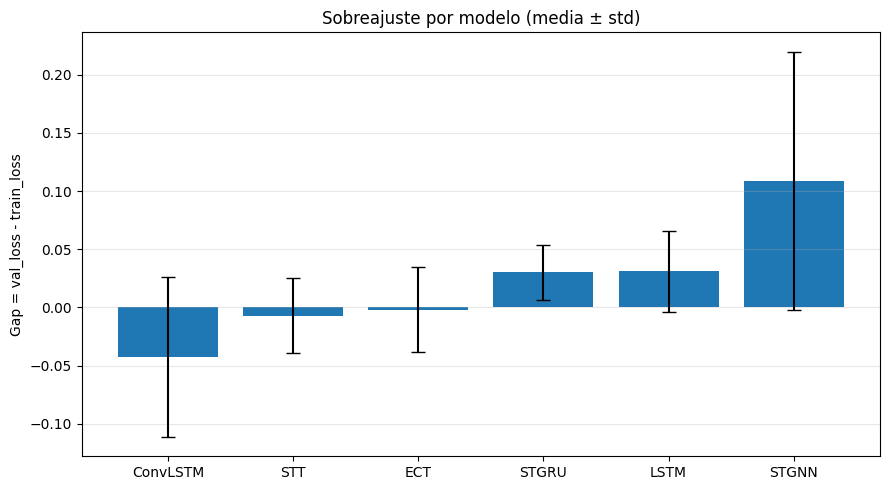

In [31]:
import matplotlib.pyplot as plt

plot_df = final_overfit.copy()

plot_df["Model"] = (
    plot_df["Model"]
    .str.replace("_CV", "", regex=False)
)

plt.figure(figsize=(9,5))

plt.bar(
    plot_df["Model"],
    plot_df["gap_mean"],
    yerr=plot_df["gap_std"],
    capsize=5
)

plt.ylabel("Gap = val_loss - train_loss")
plt.title("Sobreajuste por modelo (media ± std)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

El análisis del gap entre pérdida de validación y entrenamiento al final del entrenamiento
permite diagnosticar el comportamiento de generalización de cada modelo. Un gap positivo
indica sobreajuste (el modelo memoriza el entrenamiento pero no generaliza), un gap cercano
a cero indica ajuste balanceado, y un gap negativo puede reflejar regularización excesiva o
que el conjunto de validación resulta más fácil que el de entrenamiento. **ECT_CV y STT_CV
presentan el comportamiento más deseable**: ambos tienen gaps medios prácticamente nulos
(−0.002 y −0.007 respectivamente) con desviaciones estándar moderadas (0.036 y 0.032), lo
que indica que generalizan bien y de forma consistente sin memorizar los datos de
entrenamiento. **ConvLSTM_CV** muestra el gap medio más negativo (−0.042), pero con la
desviación estándar más alta del grupo (0.069) y un rango que va de −0.165 a +0.074,
evidenciando un comportamiento errático: en algunos folds está sobreregularizado y en otros
sobreajusta, lo que es consistente con la alta variabilidad observada en sus métricas de
desempeño. **STGRU_CV y LSTM_CV** presentan gaps positivos similares (~0.030) con
desviaciones moderadas, indicando un **sobreajuste leve pero sistemático** — el modelo
aprende patrones del training set que no transfieren perfectamente al conjunto de
validación, aunque dentro de rangos aceptables. El caso más crítico es **STGNN_CV**, que
registra el gap más alto (0.109 ± 0.111) y el rango más amplio de todo el conjunto
(de −0.050 a +0.263), lo que confirma que no solo es el modelo con peor desempeño
predictivo sino también el que más sobreajusta y con mayor inconsistencia entre folds —
una combinación que explica en gran medida sus métricas de test deficientes y su baja
robustez entre semillas documentada anteriormente.

## **13.7. Conclusión**

A lo largo del análisis comparativo realizado mediante métricas de desempeño, pruebas de
Bootstrap pareado y evaluación de robustez, **ECT_CV emerge como el modelo superior en
todas las dimensiones evaluadas**. En términos de precisión, registra el RMSE más bajo
(3.49 ± 0.97), el MAE más bajo (1.84 ± 0.72) y los valores más altos de NSE (0.716) y
KGE (0.701), superando estadísticamente a todos los demás modelos con p < 0.05 en el
Bootstrap pareado tanto para MAE como para RMSE. A esto se suma que presenta el índice de
robustez normalizada más bajo (0.374), los coeficientes de variación más pequeños en
métricas críticas como NSE (4.60%) y sMAPE (6.79%), y un gap de generalización prácticamente
nulo (−0.002 ± 0.036), lo que confirma que no solo predice con mayor precisión sino que lo
hace de forma consistente y sin sobreajuste, independientemente de la semilla de
inicialización o el fold de validación utilizado.

En el extremo opuesto, **STGNN_CV es consistentemente el peor modelo del conjunto** en
todas las métricas, con un MAPE superior al 56%, un NSE de apenas 0.28, el mayor gap de
sobreajuste (0.109 ± 0.111) y el índice de robustez más alto entre los modelos que no son
ConvLSTM_CV (0.775), evidenciando que su arquitectura de grafo espacio-temporal no logra
capturar adecuadamente la dinámica del fenómeno bajo las condiciones experimentales
definidas. En la franja intermedia, **STT_CV y LSTM_CV son estadísticamente equivalentes
en RMSE** (p = 0.906), siendo STT_CV marginalmente superior en MAE y más estable en
Pearson_r, mientras que **STGRU_CV y ConvLSTM_CV** quedan por debajo de ambos, este último
destacando negativamente por su inestabilidad extrema entre semillas. En síntesis, el
ranking definitivo consolidado es **ECT_CV > STT_CV ≈ LSTM_CV > STGRU_CV > ConvLSTM_CV >
STGNN_CV**, un ordenamiento respaldado tanto por las métricas descriptivas como por la
evidencia estadística del Bootstrap con n = 39,168 observaciones.